In [2]:
library(eSMC2,lib.loc="/data/proj2/home/students/u.srinivasan/R/x86_64-redhat-linux-gnu-library/4.3")
library(patchwork)
library(ggplot2)
library(dplyr)

In [4]:
# Define mutation rate and generation time

mu <- 2.45e-10
gen <- 0.16
#mu <- 4.0425e-09
#gen <- 0.164

# Initialize lists to store plot data
plot_data_list_newhetfile_esmc2 <- list()
plot_data_list_newhetfile_msmc <- list()
plot_data_list_newhetfile_esmc2_free_r<-list()
# Loop over chromosomes 01 to 14
for (i in 5:14) {
    # Format chromosome number with leading zeros
    chr <- sprintf("%02d", i)
    print(chr)
    
    # Construct the file paths
    filepath_newhetfile_esmc2 <- paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/ms_t2/fixed_r/results_chr_", chr, ".rds")
    filepath_newhetfile_esmc2_free_r<-paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/ms_t2/free_r_regions/mut_rate_4.0425e-09/Maesot_chr", chr, "_top4_individuals.mhs.rds")
    filepath_newhetfile_msmc <- paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/Ms_Trial_4inds/msmc_4inds_chrsep_out/Popsize_Maesot_chr", chr, "_top4_individuals.msmc2.final.txt")
    
    # Check if eSMC2 file exists
    if (file.exists(filepath_newhetfile_esmc2)) {
        # Read the eSMC2 data
        maesot_newhetfile_esmc2 <- readRDS(filepath_newhetfile_esmc2)
        # Store the data in the list
        plot_data_list_newhetfile_esmc2[[chr]] <- maesot_newhetfile_esmc2
    } else {
        print(paste("eSMC2 file not found for chromosome", chr))
    }
    #print(filepath_newhetfile_esmc2_free_r)
    # Check if eSMC2 file exists
    if (file.exists(filepath_newhetfile_esmc2_free_r)) {
        # Read the eSMC2 data
        maesot_newhetfile_esmc2_free_r <- readRDS(filepath_newhetfile_esmc2_free_r)
        # Store the data in the list
        plot_data_list_newhetfile_esmc2_free_r[[chr]] <- maesot_newhetfile_esmc2_free_r
    } else {
        print(paste("eSMC2 free r file not found for chromosome", chr))
    }

    # Check if MSMC file exists
    if (file.exists(filepath_newhetfile_msmc)) {
        # Read the MSMC data
        maesot_newhetfile_msmc <- read.table(filepath_newhetfile_msmc, header = TRUE)
        # Store the data in the list
        plot_data_list_newhetfile_msmc[[chr]] <- maesot_newhetfile_msmc
    } else {
        print(paste("MSMC file not found for chromosome", chr))
    }
}


[1] "05"
[1] "06"
[1] "07"
[1] "08"
[1] "09"
[1] "10"
[1] "11"
[1] "12"
[1] "13"
[1] "14"


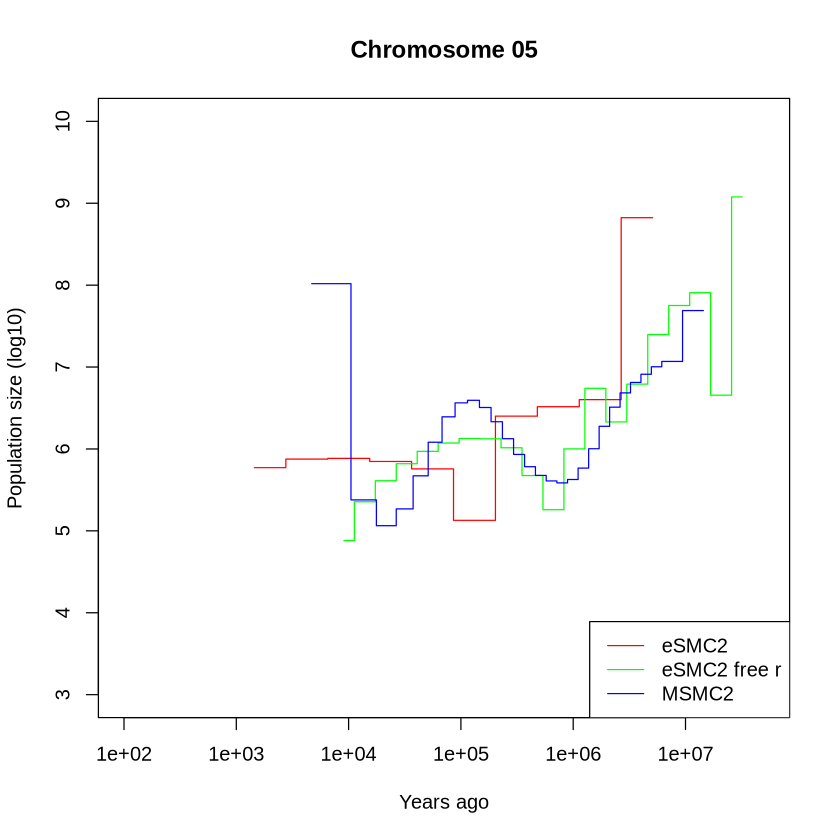

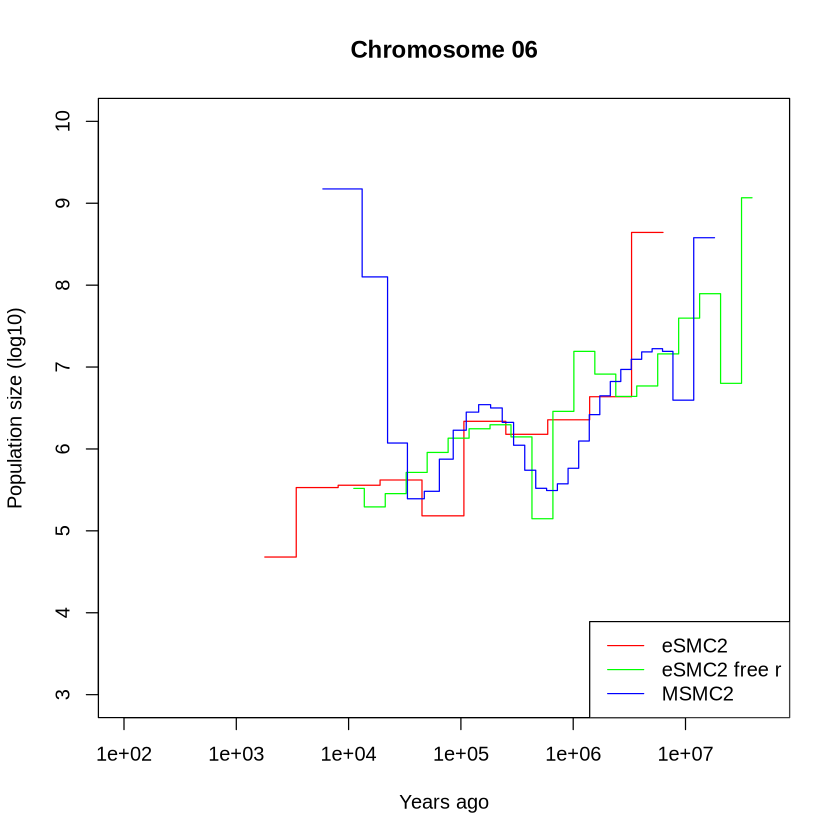

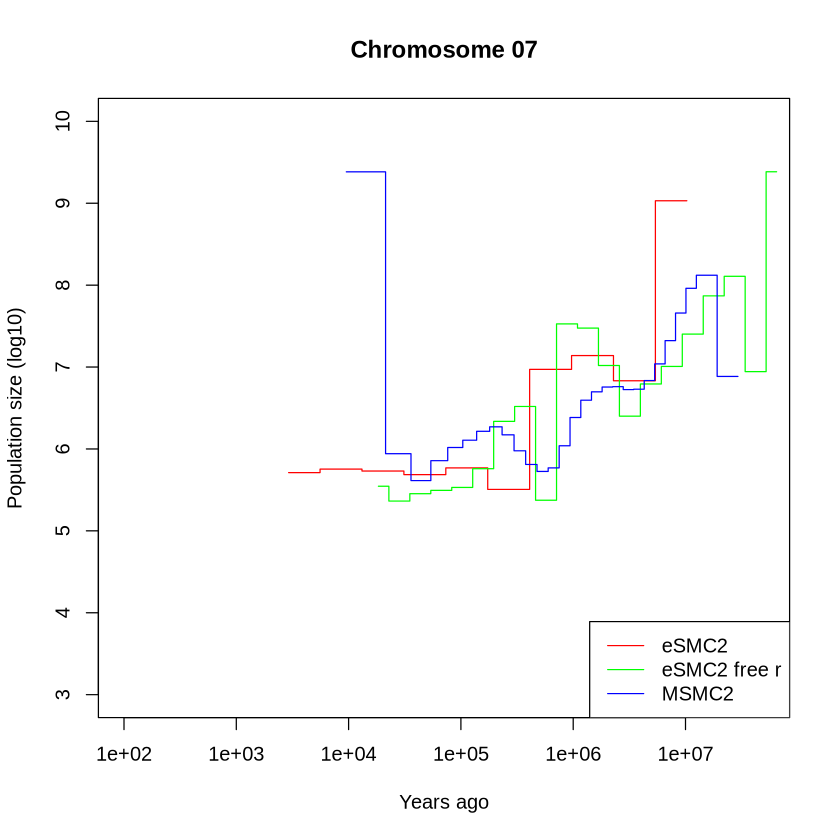

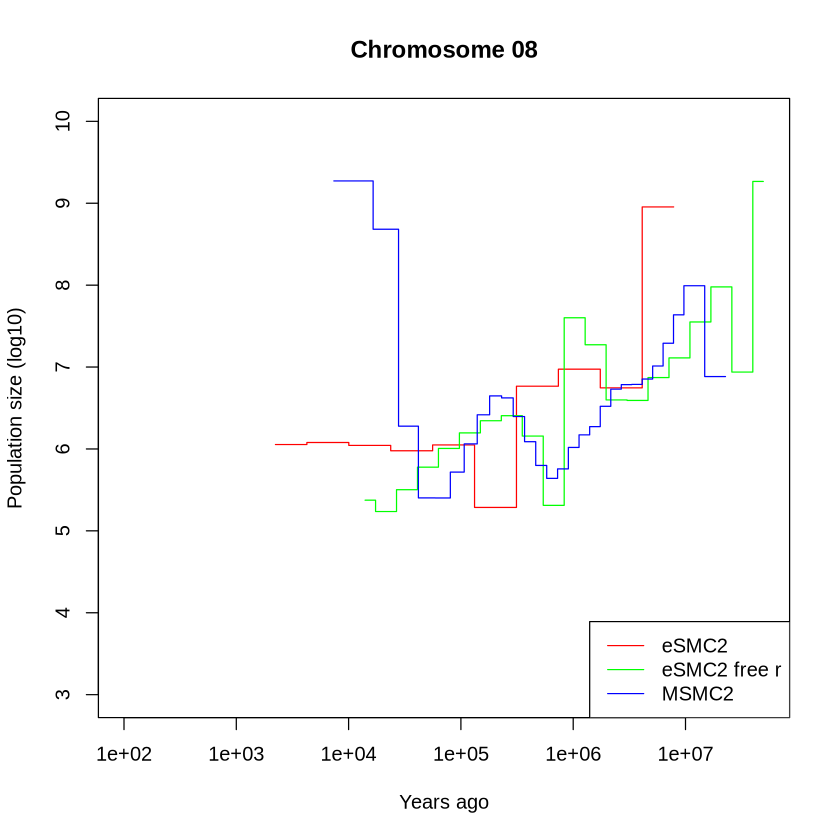

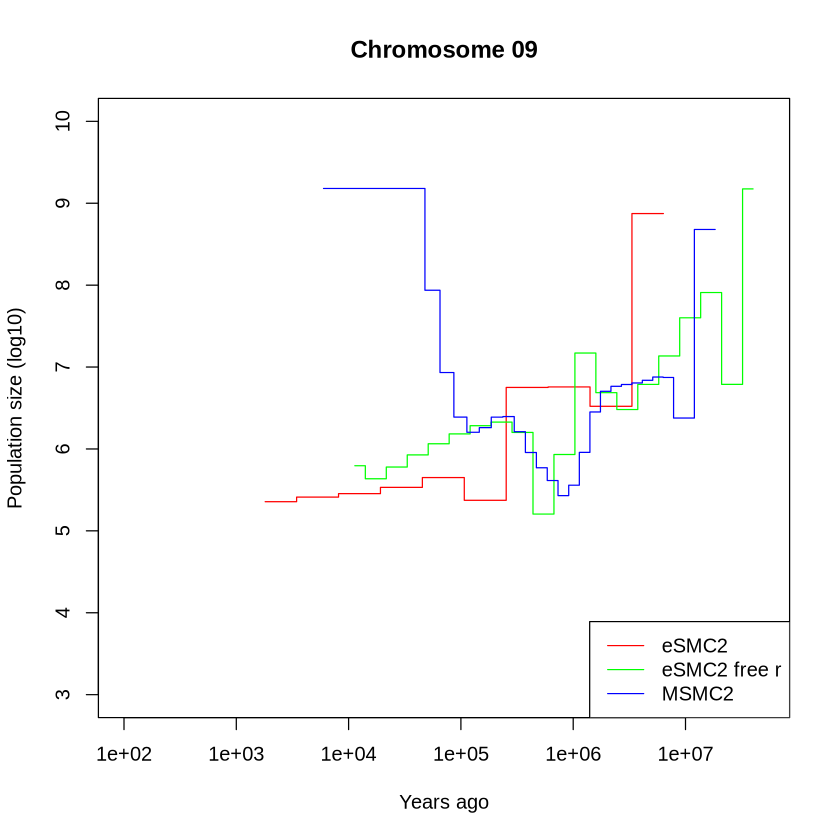

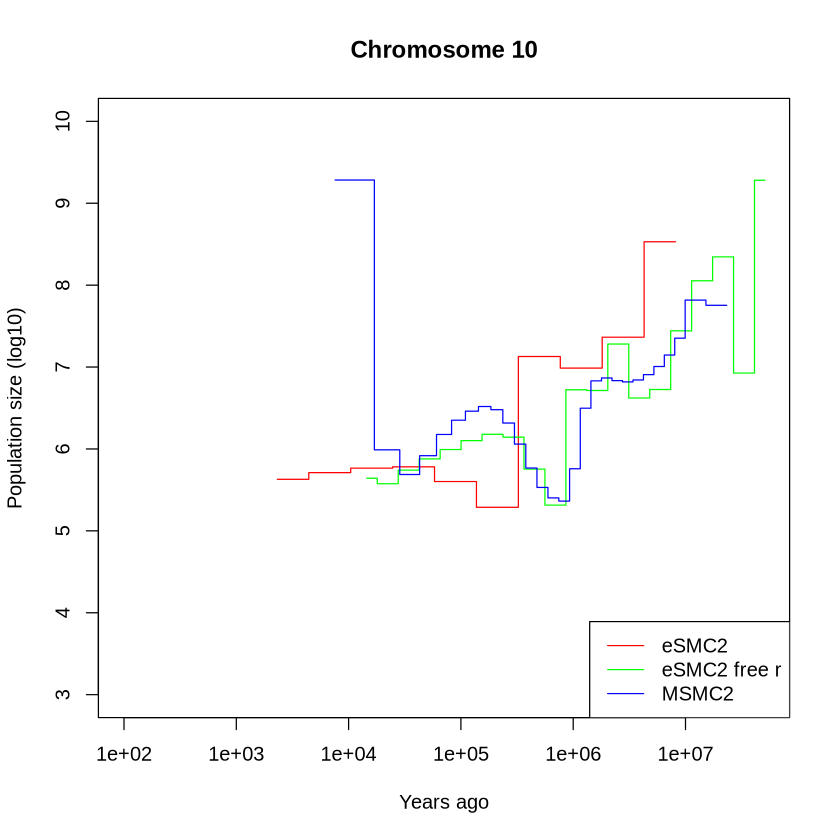

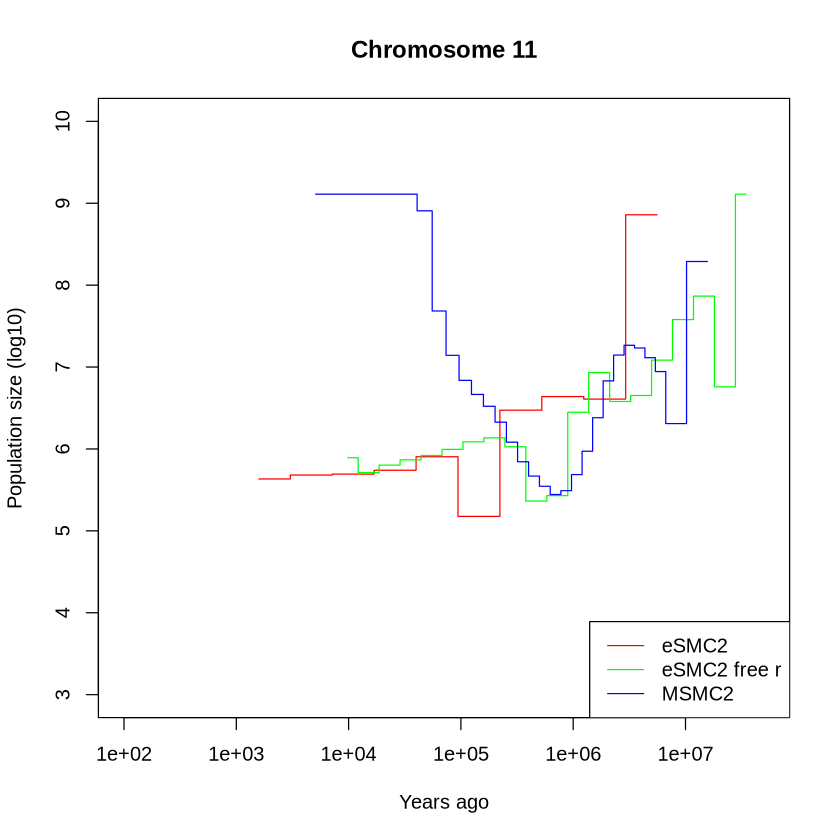

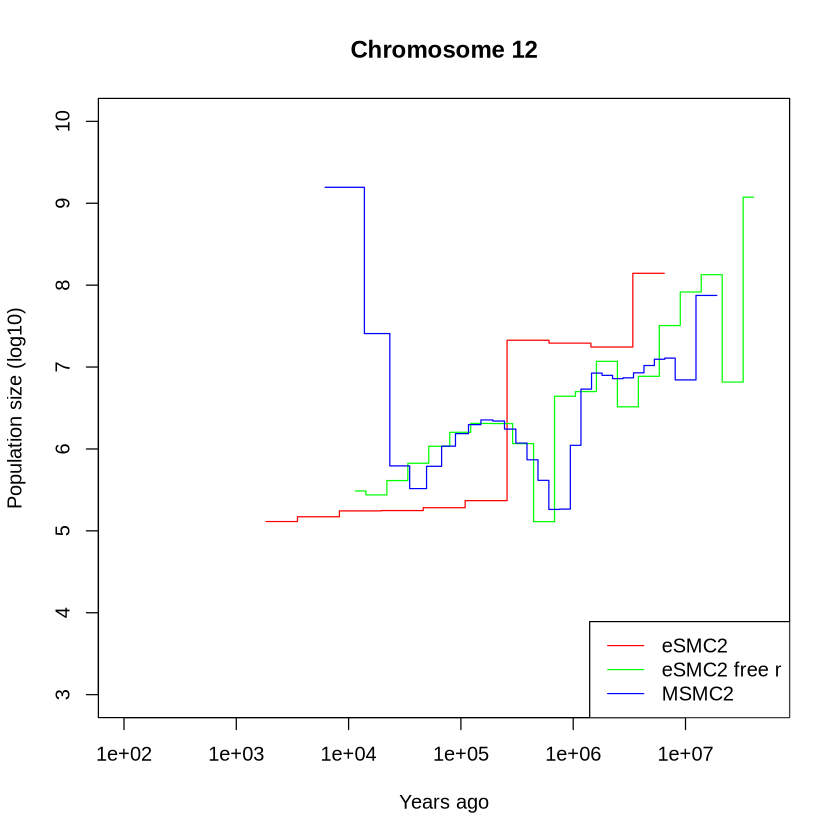

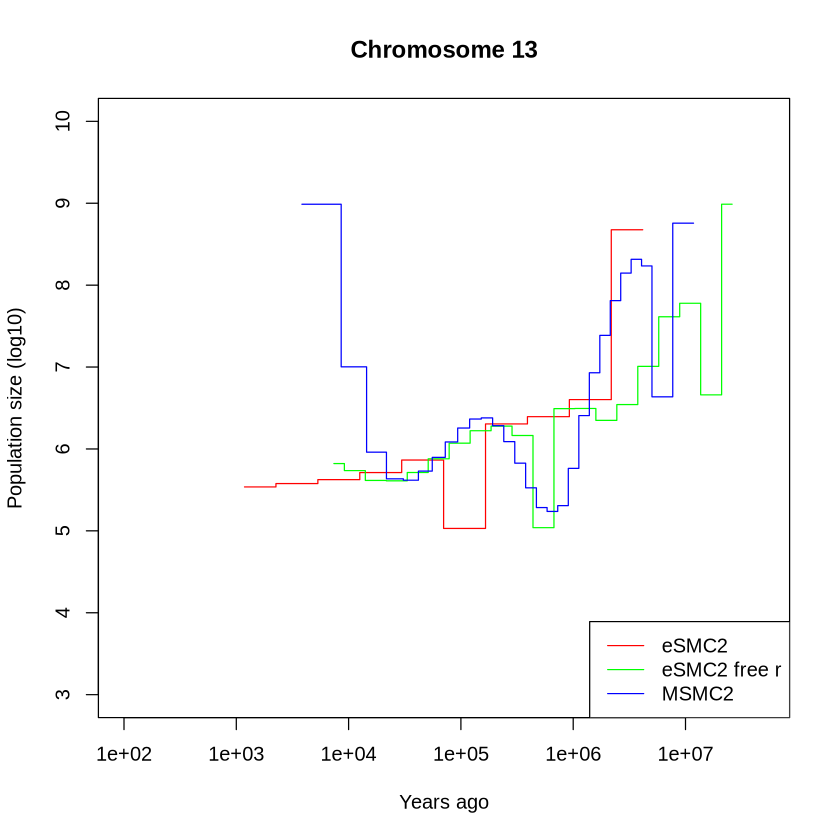

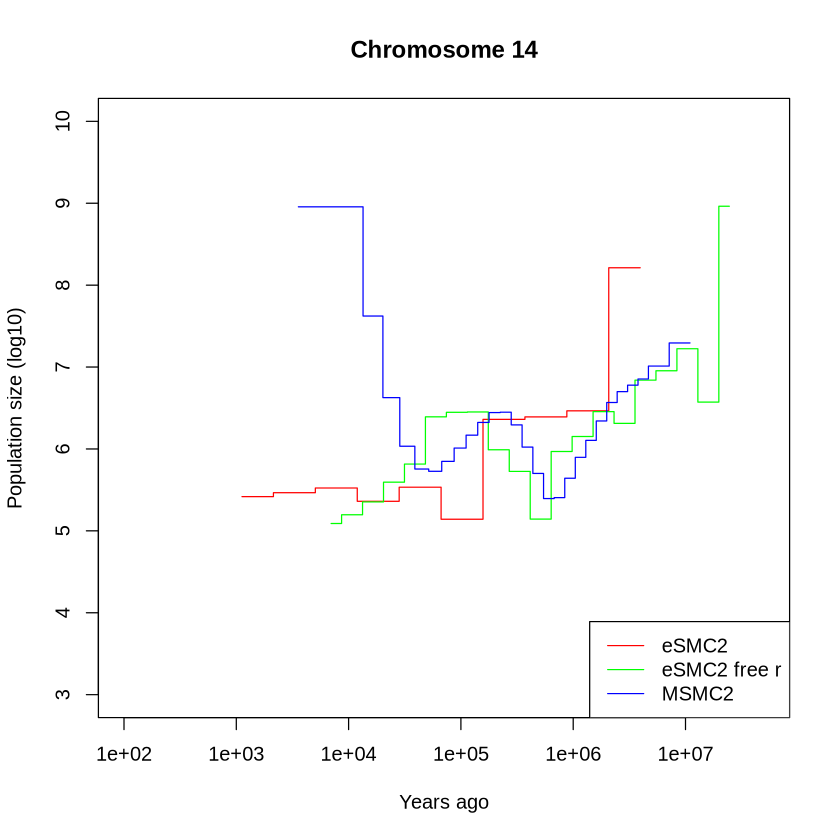

In [29]:
# Set the background color to white
par(bg = "white")  # Applies white background to all plots

# Plot each chromosome data in separate plots
for (chr in union(names(plot_data_list_newhetfile_esmc2), names(plot_data_list_newhetfile_msmc))) {

    # Extract data for the current chromosome
    maesot_newhetfile_esmc2 <- plot_data_list_newhetfile_esmc2[[chr]]
    maesot_newhetfile_msmc <- plot_data_list_newhetfile_msmc[[chr]]
    maesot_esmc2_free_r<- plot_data_list_newhetfile_esmc2_free_r[[chr]]

    # Create the plot with a white background
    plot(c(1000, 2 * 10^6),
         c(1, 1), 
         log = "x", 
         ylim = c(3, 10),
         xlim=c(100, 50000000),
         type = "n", 
         xlab = "Years ago", 
         ylab = "Population size (log10)",
         main = paste("Chromosome", chr),
         bg = "white")  # Explicitly set background to white here if needed


    Ne_t <- maesot_newhetfile_esmc2$Xi
    Ne <- mean(maesot_newhetfile_esmc2$mu / mu)
    # Plot eSMC2 data if available
    if (!is.null(maesot_newhetfile_esmc2)) {
        lines(maesot_newhetfile_esmc2$Tc * Ne * gen,
               log10(Ne_t * Ne), 
              type = "s", col = "red")
    }

    Ne_t <- maesot_esmc2_free_r$Xi
    Ne <- mean(maesot_esmc2_free_r$mu / mu)
    # Plot eSMC2 data if available
    if (!is.null(maesot_esmc2_free_r)) {
        lines(maesot_esmc2_free_r$Tc * Ne , #* gen,
               log10(Ne_t * Ne), 
              type = "s", col = "green")
    }

    # Plot MSMC data if available
    if (!is.null(maesot_newhetfile_msmc)) {
        lines(maesot_newhetfile_msmc$left_time_boundary / mu ,#* gen,
              log10((1 / maesot_newhetfile_msmc$lambda) / (mu)), 
              type = "s", col = "blue")
    }

    # Add legend only if data from at least one method is plotted
    if (!is.null(maesot_newhetfile_esmc2) || !is.null(maesot_newhetfile_msmc)) {
        legend("bottomright", legend = c("eSMC2", "eSMC2 free r","MSMC2"), col = c("red","green", "blue"), lty = c(1,1, 1))
    }
}



In [5]:

# Initialize lists to store plot data for each chromosome and "All Chromosome"
plot_data_list_newhetfile_esmc2 <- list()
plot_data_list_newhetfile_esmc2_free_r <- list()
plot_data_list_newhetfile_msmc <- list()

# Loop over each chromosome to load eSMC2 and MSMC data
for (i in 1:14) {
    # Format chromosome number with leading zeros
    chr <- sprintf("%02d", i)
    
        # Construct the file paths
    filepath_newhetfile_esmc2 <- paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/ms_t2/fixed_r/results_chr_", chr, ".rds")
    filepath_newhetfile_esmc2_free_r<-paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/ms_t2/free_r_regions/mut_rate_4.0425e-09/Maesot_chr", chr, "_top4_individuals.mhs.rds")
    filepath_newhetfile_msmc <- paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/Ms_Trial_4inds/msmc_4inds_chrsep_out/Popsize_Maesot_chr", chr, "_top4_individuals.msmc2.final.txt")
    
    # Load eSMC2 data if available
    if (file.exists(filepath_newhetfile_esmc2)) {
        maesot_esmc2 <- readRDS(filepath_newhetfile_esmc2)
        plot_data_list_newhetfile_esmc2[[chr]] <- maesot_esmc2
    } else {
        message(paste("eSMC2 file not found for chromosome", chr))
    }
    
    # Load eSMC2 data if available
    if (file.exists(filepath_newhetfile_esmc2_free_r)) {
        maesot_esmc2_free_r <- readRDS(filepath_newhetfile_esmc2_free_r)
        plot_data_list_newhetfile_esmc2_free_r[[chr]] <- maesot_esmc2_free_r
    } else {
        message(paste("eSMC2 free r file not found for chromosome", chr))
    }

    # Load MSMC data if available
    if (file.exists(filepath_newhetfile_msmc)) {
        maesot_msmc <- read.table(filepath_newhetfile_msmc, header = TRUE)
        plot_data_list_newhetfile_msmc[[chr]] <- maesot_msmc
    } else {
        message(paste("MSMC file not found for chromosome", chr))
    }
}

# Load "All Chromosome" files for eSMC2 and MSMC
filepath_esmc2_allchr <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/ms_t2/fixed_r/allchr/results_allchr.rds"
filepath_esmc2_allchr_free_r <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/ms_t2/free_r/results_allchr_free_r.rds"
filepath_msmc_allchr <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/Ms_Trial_4inds/msmc2_allchr_out/msmc2_multchrom.final.txt"

# Load "All Chromosome" eSMC2 data
if (file.exists(filepath_esmc2_allchr)) {
    maesot_esmc2_allchr <- readRDS(filepath_esmc2_allchr)
    plot_data_list_newhetfile_esmc2[["allchr"]] <- maesot_esmc2_allchr
} else {
    message("All Chromosome eSMC2 file not found.")
}

# Load "All Chromosome" eSMC2 data
if (file.exists(filepath_esmc2_allchr_free_r)) {
    maesot_esmc2_allchr_free_r <- readRDS(filepath_esmc2_allchr_free_r)
    plot_data_list_newhetfile_esmc2_free_r[["allchr"]] <- maesot_esmc2_allchr_free_r
} else {
    message("All Chromosome eSMC2 free r file not found.")
}
# Load "All Chromosome" MSMC data
if (file.exists(filepath_msmc_allchr)) {
    maesot_msmc_allchr <- read.table(filepath_msmc_allchr, header = TRUE)
    plot_data_list_newhetfile_msmc[["allchr"]] <- maesot_msmc_allchr
} else {
    message("All Chromosome MSMC file not found.")
}


In [6]:
plot_data_list_newhetfile_esmc2_free_r[["allchr"]]

$LH
[1] 83339.38

$Tc
 [1]  0.000000000  0.003398494  0.004395371  0.005684662  0.007352139
 [6]  0.009508735  0.012297924  0.015905263  0.020570739  0.026604736
[11]  0.034408680  0.044501747  0.057555405  0.074438080  0.096272936
[16]  0.124512591  0.161035759  0.208272234  0.269364543  0.348377005
[21]  0.450566121  0.582730281  0.753662035  0.974733048  1.260650626
[26]  1.630436151  2.108690535  2.727230853  3.527207050  4.561839553
[31]  5.899959887  7.630589868  9.868863999 12.763689088 16.507650643
[36] 21.349825107 27.612350295 35.711856421 46.187183465 59.735228864

$L
 [1]  640365  945465 1066967 1200440 1342617 1412065 1444541 1472289 1541186
[10] 1687457 2037658 2270432 2925071 3290527

$Xi
 [1]    0.2087138    0.2087138    0.1986598    0.1986598    0.2017691
 [6]    0.2017691    0.2326915    0.2326915    0.3198649    0.3198649
[11]    0.4750953    0.4750953    0.6671522    0.6671522    0.7663402
[16]    0.7663402    0.5110288    0.5110288    0.1166288    0.1166288
[21]    1.6145722    1.6145722    3.3851338    3.3851338    1.2625505
[26]    1.2625505    4.2322032    4.2322032    8.5235201    8.5235201
[31]   17.0369011   17.0369011   11.6706338   11.6706338   58.9469709
[36]   58.9469709   12.7114994   12.7114994 1000.0000000 1000.0000000

$beta
[1] 1

$sigma
[1] 0

$rho
 [1] 0.004456459 0.004456459 0.004456459 0.004456459 0.004456459 0.004456459
 [7] 0.004456459 0.004456459 0.004456459 0.004456459 0.004456459 0.004456459
[13] 0.004456459 0.004456459

$mu
[1] 0.0003756464

In [4]:
mu <- 4.0425e-09
gen <- 0.164

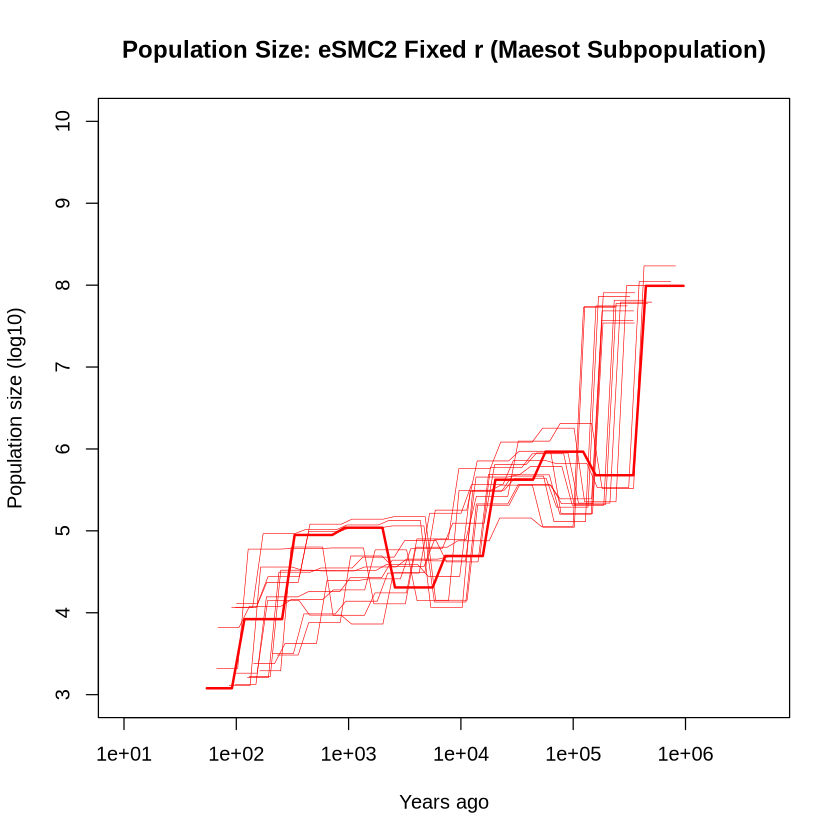

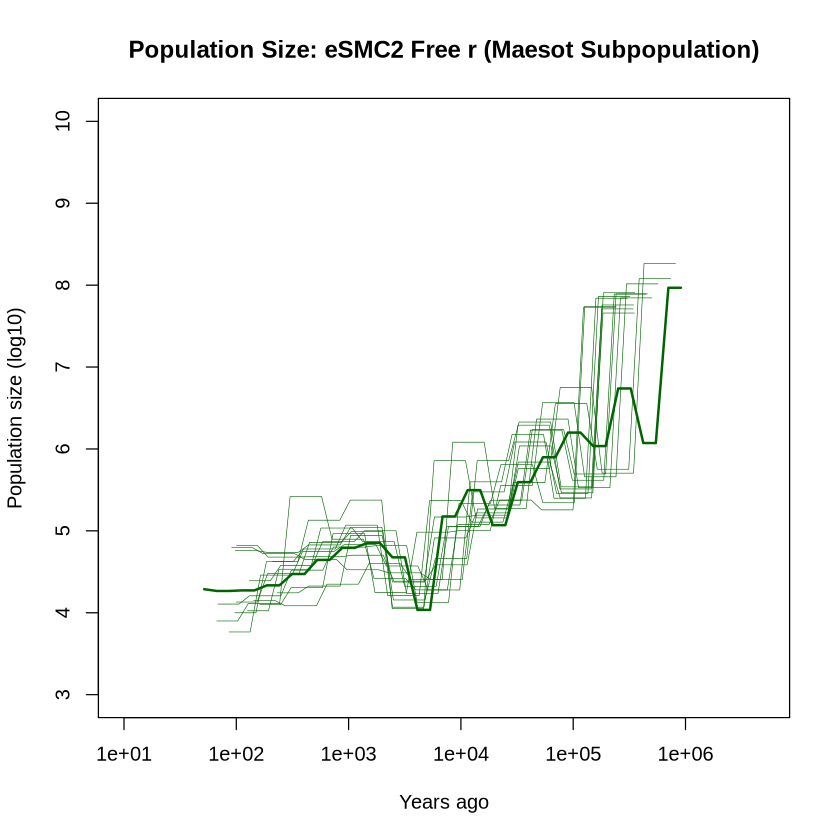

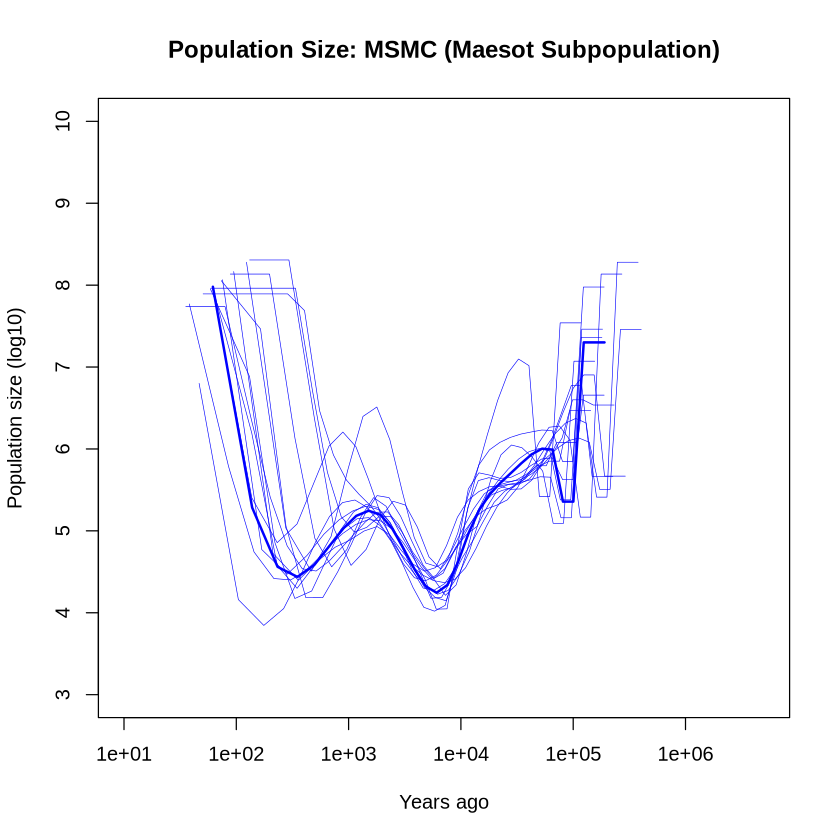

In [7]:
# Set mutation rate and generation time
mu <- 4.0425e-09  # Default mutation rate
gen <- 0.164      # Generation time

par(bg = "white")  # Applies white background to all plots

# Function to set up the plotting area
setup_plot <- function(title) {
  plot(c(1000, 5 * 10^7), 
       c(1, 1), 
       log = "x", 
       ylim = c(3, 10), 
       xlim = c(10, 5 * 10^6), 
       type = "n", 
       xlab = "Years ago", 
       ylab = "Population size (log10)", 
       main = title)
}

# Plot eSMC2 Fixed r
setup_plot("Population Size: eSMC2 Fixed r (Maesot Subpopulation)")
for (chr in names(plot_data_list_newhetfile_esmc2)) {
  if (chr != "allchr" && !is.null(plot_data_list_newhetfile_esmc2[[chr]])) {
    Ne_t <- plot_data_list_newhetfile_esmc2[[chr]]$Xi
    Ne <- mean(plot_data_list_newhetfile_esmc2[[chr]]$mu / mu)
    lines(plot_data_list_newhetfile_esmc2[[chr]]$Tc * Ne * gen,
          log10(Ne_t * Ne), col = "red", lwd = 0.5)
  }
}
if (!is.null(plot_data_list_newhetfile_esmc2[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "red", lwd = 2)
}

# Plot eSMC2 Free r
setup_plot("Population Size: eSMC2 Free r (Maesot Subpopulation)")
for (chr in names(plot_data_list_newhetfile_esmc2_free_r)) {
  if (chr != "allchr" && !is.null(plot_data_list_newhetfile_esmc2_free_r[[chr]])) {
    Ne_t <- plot_data_list_newhetfile_esmc2_free_r[[chr]]$Xi
    Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[[chr]]$mu / mu)
    lines(plot_data_list_newhetfile_esmc2_free_r[[chr]]$Tc * Ne * gen,
          log10(Ne_t * Ne), col = "darkgreen", lwd = 0.5)
  }
}
if (!is.null(plot_data_list_newhetfile_esmc2_free_r[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "darkgreen", lwd = 2)
}

# Plot MSMC
setup_plot("Population Size: MSMC (Maesot Subpopulation)")
for (chr in names(plot_data_list_newhetfile_msmc)) {
  if (chr != "allchr" && !is.null(plot_data_list_newhetfile_msmc[[chr]])) {
    lines(plot_data_list_newhetfile_msmc[[chr]]$left_time_boundary / mu * gen,
          log10((1 / plot_data_list_newhetfile_msmc[[chr]]$lambda) / mu), 
          col = "blue", lwd = 0.5)
  }
}
if (!is.null(plot_data_list_newhetfile_msmc[["allchr"]])) {
  lines(plot_data_list_newhetfile_msmc[["allchr"]]$left_time_boundary / mu * gen,
        log10((1 / plot_data_list_newhetfile_msmc[["allchr"]]$lambda) / mu), 
        col = "blue", lwd = 2)

      
}



In [8]:
if (!is.null(plot_data_list_newhetfile_esmc2_free_r[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Xi
  
  Nt <- mean(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$mu / mu)
}

log10(Ne_t * Ne)

[1] 4.287680 4.287680 4.266239 4.266239 4.272984 4.272984 4.334910 4.334910
 [9] 4.473096 4.473096 4.644910 4.644910 4.792354 4.792354 4.852551 4.852551
[17] 4.676575 4.676575 4.034935 4.034935 5.176187 5.176187 5.497705 5.497705
[25] 5.069378 5.069378 5.594696 5.594696 5.898748 5.898748 6.199520 6.199520
[33] 6.035224 6.035224 6.738591 6.738591 6.072326 6.072326 7.968129 7.968129

In [6]:
 # Compute Tc and Ne values
Tc <- plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Xi / mu * gen
Tc

[1]     7850728     7850728     6954521     6954521     7373283     7373283
 [7]     8375891     8375891    12102746    12102746    20311345    20311345
[13]    31724235    31724235    36653975    36653975    15884991    15884991
[19]     4569387     4569387   166512021   166512021   211823434   211823434
[25]    80357985    80357985   141312470   141312470   263081570   263081570
[31]   433688066   433688066   970145396   970145396  2059645280  2059645280
[37]   500282315   500282315 40568954855 40568954855

In [7]:
Ne_values <- plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Xi*mean(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$mu / mu)
Ne_values

[1]     20260.57     20260.57     17947.71     17947.71     19028.41
 [6]     19028.41     21615.87     21615.87     31233.86     31233.86
[11]     52417.99     52417.99     81871.52     81871.52     94593.82
[16]     94593.82     40994.79     40994.79     11792.33     11792.33
[21]    429721.70    429721.70    546657.99    546657.99    207381.85
[26]    207381.85    364688.60    364688.60    678941.13    678941.13
[31]   1119229.55   1119229.55   2503678.29   2503678.29   5315377.67
[36]   5315377.67   1291090.98   1291090.98 104697308.29 104697308.29

In [5]:

 
  
  # Find the index of the minimum Ne value
  min_index <- which.min(Ne_values)

  # Find the corresponding Tc value
  min_Tc <- Tc[min_index]

  # Compute the actual minimum Ne value (not log-transformed)
  min_Ne <- Ne_values[min_index]

  # Print the results
  print(paste("The lowest value of Ne is:", min_Ne))
  print(paste("The corresponding Tc value is:", min_Tc))




ERROR: Error: object 'Ne_values' not found


In [9]:
# Set mutation rate and generation time
mu <- 4.0425e-09 # Default mutation rate
gen <- 0.164   # Generation time

# Set mutation rate and generation time
#mu <- 2.0625e-8 # Default mutation rate
#gen <- 0.5  # Generation time
png("Maesot_msmce_esmc.png")
par(bg = "white")  # Applies white background to all plots

# Set up plot area with logarithmic x-axis
plot(c(1000, 5 * 10^7), 
     c(1, 1), 
     log = "x", 
     ylim = c(3, 10), 
     xlim = c(10, 5 * 10^6), 
     type = "n", 
     xlab = "Years ago", 
     ylab = "Population size (log10)", 
     main = "Population Size, Maesot Subpopulation")

# Loop through each chromosome to plot lighter lines for individual chromosomes
for (chr in names(plot_data_list_newhetfile_esmc2)) {
  # Skip if "allchr" as we will plot it separately
  if (chr != "allchr") {
    # eSMC2 plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_esmc2[[chr]])) {
      Ne_t <- plot_data_list_newhetfile_esmc2[[chr]]$Xi
      Ne <- mean(plot_data_list_newhetfile_esmc2[[chr]]$mu / mu)
      lines(plot_data_list_newhetfile_esmc2[[chr]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "red", lwd = 0.5)
    }
    
    # eSMC2 Free_r plot for each chromosome (mu = 1e-08)
    if (!is.null(plot_data_list_newhetfile_esmc2_free_r[[chr]])) {
      Ne_t <- plot_data_list_newhetfile_esmc2_free_r[[chr]]$Xi
      Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[[chr]]$mu / mu)  # Fixed mu for free_r
      lines(plot_data_list_newhetfile_esmc2_free_r[[chr]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "darkgreen", lwd = 0.5)  # Orange color for free_r
    }

    # MSMC plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_msmc[[chr]])) {
      lines(plot_data_list_newhetfile_msmc[[chr]]$left_time_boundary / mu * gen,
            log10((1 / plot_data_list_newhetfile_msmc[[chr]]$lambda) / mu), 
            col = "blue", lwd = 0.5)
    }
  }
}

# Plot "All Chromosome" lines in bold
# eSMC2 "All Chromosome"
if (!is.null(plot_data_list_newhetfile_esmc2[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "red", lwd = 2)
}

# eSMC2 Free_r "All Chromosome" (mu = 1e-08)
if (!is.null(plot_data_list_newhetfile_esmc2_free_r[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "darkgreen", lwd = 2)
}

# MSMC "All Chromosome"
if (!is.null(plot_data_list_newhetfile_msmc[["allchr"]])) {
  lines(plot_data_list_newhetfile_msmc[["allchr"]]$left_time_boundary / mu * gen,
        log10((1 / plot_data_list_newhetfile_msmc[["allchr"]]$lambda) / mu), 
        col = "blue", lwd = 2)
}

# Add a legend for the main lines
legend("bottomright", 
       legend = c(expression("eSMC2 Fixed "*italic(r)), 
                  expression("eSMC2 Free "*italic(r)), 
       "MSMC"),
       col = c("red", "darkgreen", "blue"), lty = 1, lwd = 2)

dev.off()

pdf 
  2

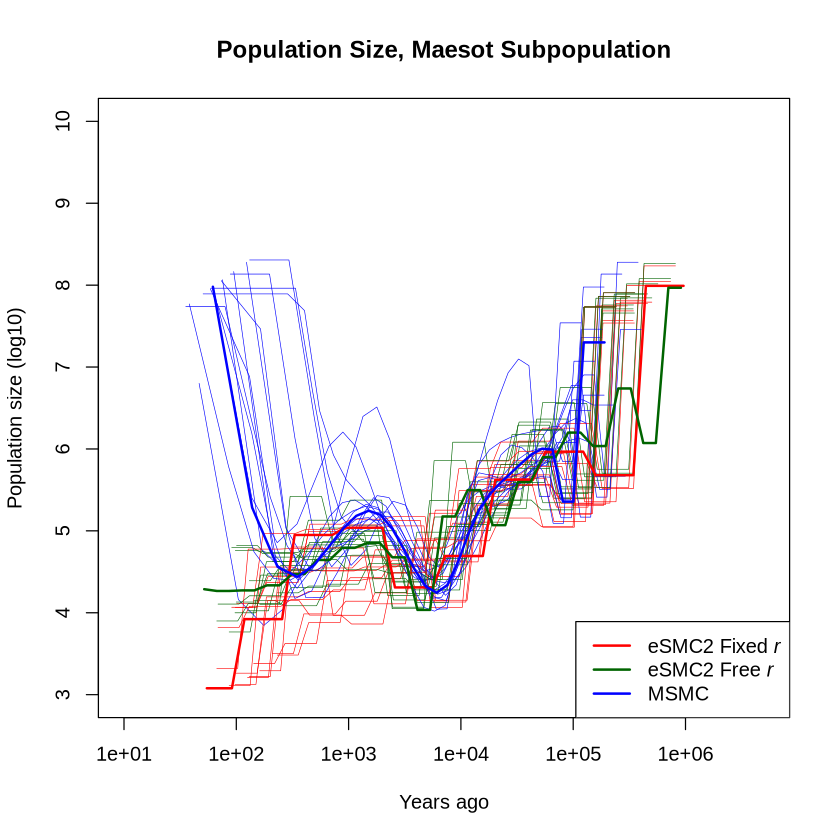

In [10]:
# Set mutation rate and generation time
#mu <- 4.0425e-09 # Default mutation rate
#gen <- 0.164   # Generation time

# Set mutation rate and generation time
#mu <- 2.0625e-8 # Default mutation rate
#gen <- 0.5  # Generation time

par(bg = "white")  # Applies white background to all plots

# Set up plot area with logarithmic x-axis
plot(c(1000, 5 * 10^7), 
     c(1, 1), 
     log = "x", 
     ylim = c(3, 10), 
     xlim = c(10, 5 * 10^6), 
     type = "n", 
     xlab = "Years ago", 
     ylab = "Population size (log10)", 
     main = "Population Size, Maesot Subpopulation")

# Loop through each chromosome to plot lighter lines for individual chromosomes
for (chr in names(plot_data_list_newhetfile_esmc2)) {
  # Skip if "allchr" as we will plot it separately
  if (chr != "allchr") {
    # eSMC2 plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_esmc2[[chr]])) {
      Ne_t <- plot_data_list_newhetfile_esmc2[[chr]]$Xi
      Ne <- mean(plot_data_list_newhetfile_esmc2[[chr]]$mu / mu)
      lines(plot_data_list_newhetfile_esmc2[[chr]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "red", lwd = 0.5)
    }
    
    # eSMC2 Free_r plot for each chromosome (mu = 1e-08)
    if (!is.null(plot_data_list_newhetfile_esmc2_free_r[[chr]])) {
      Ne_t <- plot_data_list_newhetfile_esmc2_free_r[[chr]]$Xi
      Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[[chr]]$mu / mu)  # Fixed mu for free_r
      lines(plot_data_list_newhetfile_esmc2_free_r[[chr]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "darkgreen", lwd = 0.5)  # Orange color for free_r
    }

    # MSMC plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_msmc[[chr]])) {
      lines(plot_data_list_newhetfile_msmc[[chr]]$left_time_boundary / mu * gen,
            log10((1 / plot_data_list_newhetfile_msmc[[chr]]$lambda) / mu), 
            col = "blue", lwd = 0.5)
    }
  }
}

# Plot "All Chromosome" lines in bold
# eSMC2 "All Chromosome"
if (!is.null(plot_data_list_newhetfile_esmc2[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "red", lwd = 2)
}

# eSMC2 Free_r "All Chromosome" (mu = 1e-08)
if (!is.null(plot_data_list_newhetfile_esmc2_free_r[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "darkgreen", lwd = 2)
}

# MSMC "All Chromosome"
if (!is.null(plot_data_list_newhetfile_msmc[["allchr"]])) {
  lines(plot_data_list_newhetfile_msmc[["allchr"]]$left_time_boundary / mu * gen,
        log10((1 / plot_data_list_newhetfile_msmc[["allchr"]]$lambda) / mu), 
        col = "blue", lwd = 2)
}

# Add a legend for the main lines
legend("bottomright", 
       legend = c(expression("eSMC2 Fixed "*italic(r)), 
                  expression("eSMC2 Free "*italic(r)), 
       "MSMC"),
       col = c("red", "darkgreen", "blue"), lty = 1, lwd = 2)



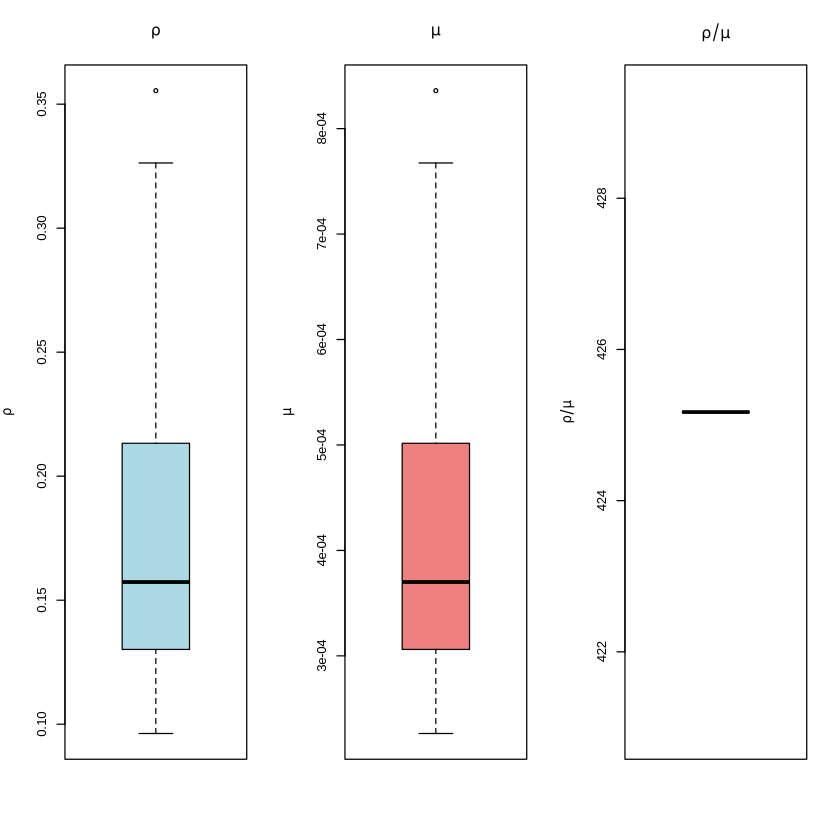

In [33]:
# Extract rho, mu, and rho/mu for each chromosome
rho_values_esmc2 <- sapply(plot_data_list_newhetfile_esmc2, function(chr_data) {
    if (!is.null(chr_data)) {
        return(chr_data$rho)
    } else {
        return(NA)  # Handle missing data
    }
})

mu_values_esmc2 <- sapply(plot_data_list_newhetfile_esmc2, function(chr_data) {
    if (!is.null(chr_data)) {
        return(chr_data$mu)
    } else {
        return(NA)  # Handle missing data
    }
})

rho_mu_ratios_esmc2 <- sapply(plot_data_list_newhetfile_esmc2, function(chr_data) {
    if (!is.null(chr_data)) {
        return(chr_data$rho / chr_data$mu)
    } else {
        return(NA)  # Handle missing data
    }
})

# Remove chromosomes with missing data
valid_indices_esmc2 <- !is.na(rho_values_esmc2) & !is.na(rho_mu_ratios_esmc2) & !is.na(mu_values_esmc2)
rho_values_esmc2 <- rho_values_esmc2[valid_indices_esmc2]
rho_mu_ratios_esmc2 <- rho_mu_ratios_esmc2[valid_indices_esmc2]
mu_values_esmc2 <- mu_values_esmc2[valid_indices_esmc2]

# Create a data frame for plotting
boxplot_data_esmc2 <- data.frame(
    Chromosome = names(rho_values_esmc2),
    Rho = rho_values_esmc2,
    Rho_Mu_Ratio = rho_mu_ratios_esmc2,
    Mu = mu_values_esmc2
)

# Set up plotting layout
par(mfrow = c(1, 3), bg = "white")  # Arrange plots in one row with three columns

# Boxplot for rho
boxplot(boxplot_data_esmc2$Rho,
        main = expression(rho),
        ylab = expression(rho),
        col = "lightblue")


# Boxplot for mu
boxplot(boxplot_data_esmc2$Mu,
        main = expression(mu),
        ylab = expression(mu),
        col = "lightcoral")

# Boxplot for rho/mu
boxplot(boxplot_data_esmc2$Rho_Mu_Ratio,
        main = expression(rho / mu),
        ylab = expression(rho / mu),
        col = "lightgreen")

# Reset plotting layout
par(mfrow = c(1, 1), bg = "white")


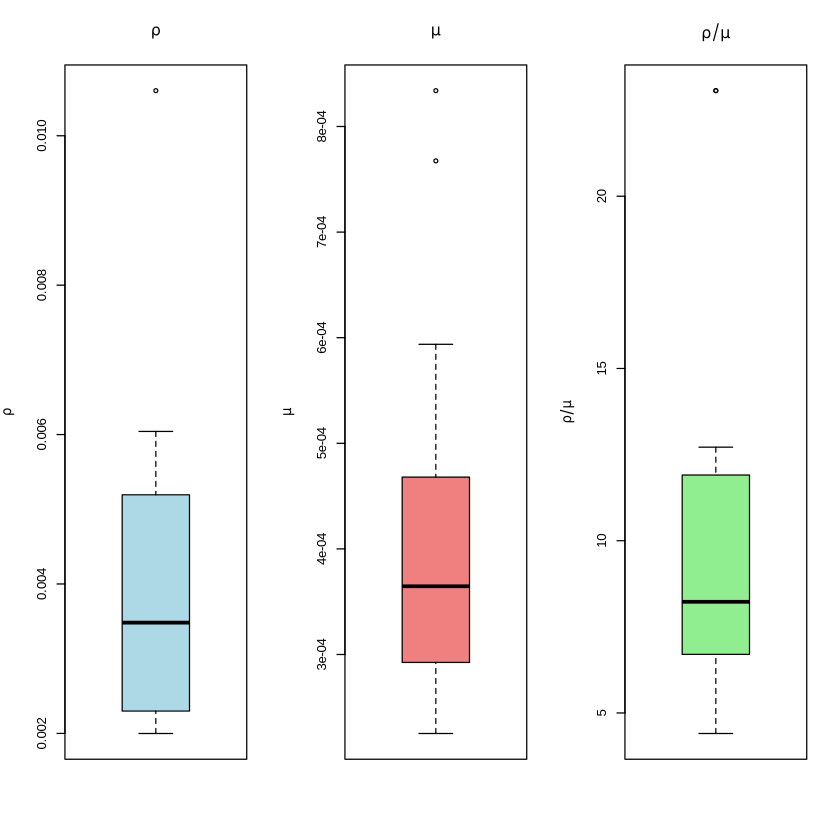

In [31]:
# Extract rho, mu, and rho/mu for each chromosome
rho_values <- sapply(plot_data_list_newhetfile_esmc2_free_r, function(chr_data) {
    if (!is.null(chr_data)) {
        return(chr_data$rho)
    } else {
        return(NA)  # Handle missing data
    }
})

mu_values <- sapply(plot_data_list_newhetfile_esmc2_free_r, function(chr_data) {
    if (!is.null(chr_data)) {
        return(chr_data$mu)
    } else {
        return(NA)  # Handle missing data
    }
})

rho_mu_ratios <- sapply(plot_data_list_newhetfile_esmc2_free_r, function(chr_data) {
    if (!is.null(chr_data)) {
        return(chr_data$rho / chr_data$mu)
    } else {
        return(NA)  # Handle missing data
    }
})

# Remove chromosomes with missing data
valid_indices <- !is.na(rho_values) & !is.na(rho_mu_ratios) & !is.na(mu_values)
rho_values <- rho_values[valid_indices]
rho_mu_ratios <- rho_mu_ratios[valid_indices]
mu_values <- mu_values[valid_indices]

# Create a data frame for plotting
boxplot_data <- data.frame(
    Chromosome = names(rho_values),
    Rho = rho_values,
    Rho_Mu_Ratio = rho_mu_ratios,
    Mu = mu_values
)

# Set up plotting layout
par(mfrow = c(1, 3), bg = "white")  # Arrange plots in one row with three columns

# Boxplot for rho
boxplot(boxplot_data$Rho,
        main = expression(rho),
        ylab = expression(rho),
        col = "lightblue")

# Boxplot for mu
boxplot(boxplot_data$Mu,
        main = expression(mu),
        ylab = expression(mu),
        col = "lightcoral")

# Boxplot for rho/mu
boxplot(boxplot_data$Rho_Mu_Ratio,
        main = expression(rho / mu),
        ylab = expression(rho / mu),
        col = "lightgreen")


# Reset plotting layout
par(mfrow = c(1, 1), bg = "white")



In [11]:
mu <- 4.0425e-09  # Default mutation rate
gen <- 0.164     # Generation time

# Directories for various eSMC2 datasets
base_dir_regions <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/ms_t2/free_r/mut_rate_4.0425e-09/"
base_dir_free_r <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/ms_t2/free_r_regions/mut_rate_4.0425e-09/"

# Initialize lists to store the data
plot_data_list_newhetfile_esmc2_regions <- list()
plot_data_list_newhetfile_esmc2_free_r <- list()
plot_data_list_newhetfile_esmc2_regions_free_r <- list()

# Loop over each chromosome to load eSMC2 and region-specific data
for (i in 1:14) {
    # Format chromosome number with leading zeros
    chr <- sprintf("%02d", i)
    
    # ----- Load Region-specific eSMC2 Free r Files -----
    # Construct a search pattern for region files
    search_pattern_regions <- paste0("Maesot_chr", chr, "_top4_individuals_region_.*\\.rds")
    region_files <- list.files(path = base_dir_regions, pattern = search_pattern_regions, full.names = TRUE)
    print(region_files)
    # Check and load all region files for the current chromosome
    
    data_list_regions <- lapply(region_files, readRDS)  # Read RDS files
    plot_data_list_newhetfile_esmc2_regions[[chr]] <- data_list_regions
    
    
    # ----- Load eSMC2 Free r Files -----
    filepath_free_r <- paste0(base_dir_free_r, "Maesot_chr", chr, "_top4_individuals.mhs.rds")
    if (file.exists(filepath_free_r)) {
        maesot_esmc2_free_r <- readRDS(filepath_free_r)
        plot_data_list_newhetfile_esmc2_free_r[[chr]] <- maesot_esmc2_free_r
    } else {
        message(paste("eSMC2 Free r file not found for chromosome", chr))
    }
    
   
}

# ----- Load "All Chromosome" Files -----
# Paths for "All Chromosome" files
filepath_allchr_regions <- paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/Ms_Trial_4inds/esmc_4inds_allchr/me_09/results_allchr_regions_free_r.rds")
filepath_allchr_free_r <- paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/ms_t2/free_r/results_allchr_free_r.rds")

# Load "All Chromosome" Region-specific data
if (file.exists(filepath_allchr_regions)) {
    data_allchr_regions <- readRDS(filepath_allchr_regions)
    plot_data_list_newhetfile_esmc2_regions[["allchr"]] <- data_allchr_regions
} else {
    message("All Chromosome region-specific file not found.")
}

# Load "All Chromosome" Free r data
if (file.exists(filepath_allchr_free_r)) {
    data_allchr_free_r <- readRDS(filepath_allchr_free_r)
    plot_data_list_newhetfile_esmc2_free_r[["allchr"]] <- data_allchr_free_r
} else {
    message("All Chromosome eSMC2 Free r file not found.")
}


str(plot_data_list_newhetfile_esmc2_regions)
#str(plot_data_list_newhetfile_esmc2_free_r)



[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/ms_t2/free_r/mut_rate_4.0425e-09//Maesot_chr01_top4_individuals_region_92901-457931,460312-575900.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/ms_t2/free_r/mut_rate_4.0425e-09//Maesot_chr02_top4_individuals_region_105801-447300,450451-862500.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/ms_t2/free_r/mut_rate_4.0425e-09//Maesot_chr03_top4_individuals_region_70631-597816,600276-1003060.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/ms_t2/free_r/mut_rate_4.0425e-09//Maesot_chr04_top4_individuals_region_91421-545800,614901-642003,644530-935030,983081-1143990.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/ms_t2/free_r/mut_rate_4.0425e-09//Maesot_chr05_top4_individuals_region_37901-455740,457253-1321390.mh

In [12]:

# Define directories for the regions_fixed_r data
base_regions_fixed_r <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/ms_t2/fixed_r_regiosn/mut_rate_4.0425e-09/"

# Initialize list for regions_fixed_r data
plot_data_list_newhetfile_esmc2_regions_fixed_r <- list()

# Loop over each chromosome to load regions_fixed_r data
for (i in 1:14) {
    # Format chromosome number with leading zeros
    chr <- sprintf("%02d", i)
    
    # ----- Load Region-specific Fixed r Files ----- 
    # Construct a search pattern for region files
    search_pattern_regions_fixed_r <- paste0("Maesot_chr", chr, "_top4_individuals_region_.*\\.rds")
    region_files_fixed_r <- list.files(path = base_regions_fixed_r, pattern = search_pattern_regions_fixed_r, full.names = TRUE)
    print(region_files_fixed_r)
    
    # Check and load all region files for the current chromosome
    if (length(region_files_fixed_r) > 0) {
        data_list_regions_fixed_r <- lapply(region_files_fixed_r, readRDS)  # Read RDS files
        plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]] <- data_list_regions_fixed_r
    } else {
        message(paste("No region-specific Fixed r files found for chromosome", chr))
    }
}

# ----- Load "All Chromosome" Files for Fixed r -----
# Paths for "All Chromosome" Fixed r files
filepath_allchr_regions_fixed_r <- paste0("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/ms_t2/fixed_r_regiosn/results_allchr_regions.rds")

# Load "All Chromosome" Fixed r region-specific data
if (file.exists(filepath_allchr_regions_fixed_r)) {
    data_allchr_regions_fixed_r <- readRDS(filepath_allchr_regions_fixed_r)
    plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]] <- data_allchr_regions_fixed_r
} else {
    message("All Chromosome Fixed r region-specific file not found.")
}

# Check the structure of the loaded data
str(plot_data_list_newhetfile_esmc2_regions_fixed_r)



[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/ms_t2/fixed_r_regiosn/mut_rate_4.0425e-09//Maesot_chr01_top4_individuals_region_92901-457931,460312-575900.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/ms_t2/fixed_r_regiosn/mut_rate_4.0425e-09//Maesot_chr02_top4_individuals_region_105801-447300,450451-862500.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/ms_t2/fixed_r_regiosn/mut_rate_4.0425e-09//Maesot_chr03_top4_individuals_region_70631-597816,600276-1003060.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/ms_t2/fixed_r_regiosn/mut_rate_4.0425e-09//Maesot_chr04_top4_individuals_region_91421-545800,614901-642003,644530-935030,983081-1143990.mhs.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Demo_r_eSMC2_MSMC2/ms_t2/fixed_r_regiosn/mut_rate_4.0425e-09//Maesot_chr05_top4_indi

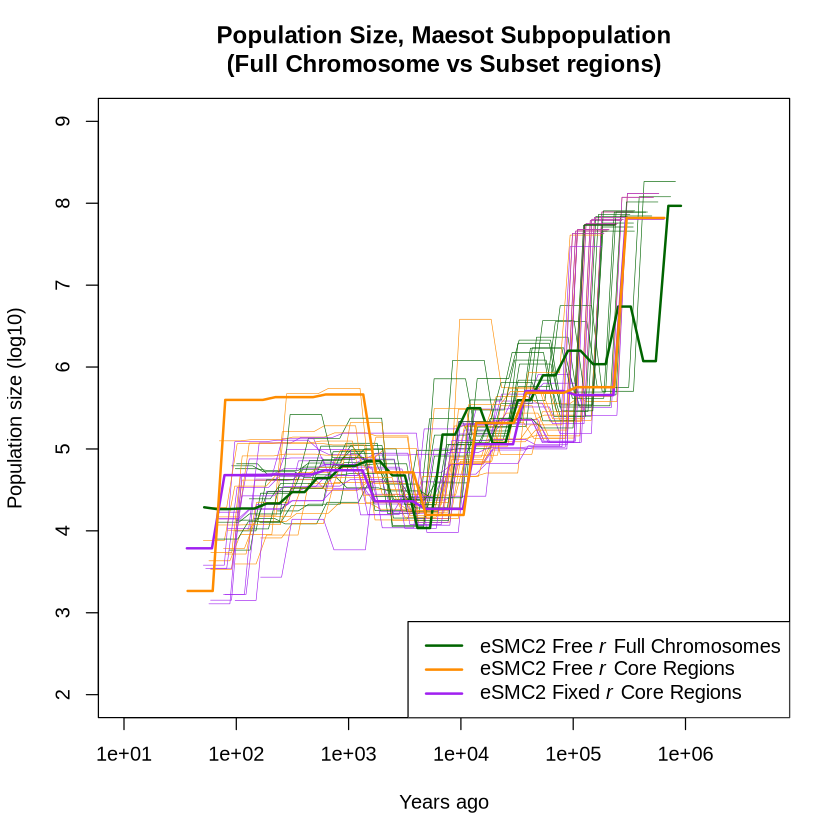

In [13]:
# Set mutation rate and generation time
mu <- 4.0425e-09  # Default mutation rate
gen <- 0.164   # Generation time

par(bg = "white")  # Applies white background to all plots

# Set up plot area with logarithmic x-axis
plot(c(1000, 5 * 10^7), 
     c(1, 1), 
     log = "x", 
     ylim = c(2, 9), 
     xlim = c(10, 5 * 10^6), 
     type = "n", 
     xlab = "Years ago", 
     ylab = "Population size (log10)", 
     main = paste("Population Size, Maesot Subpopulation", 
             "(Full Chromosome vs Subset regions)", sep = "\n"))


# Loop through each chromosome to plot lighter lines for individual chromosomes
for (chr in names(plot_data_list_newhetfile_esmc2_free_r)) {

  # Skip "allchr" as it will be plotted separately
  if (chr != "allchr") {
    # eSMC2 Free_r plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_esmc2_free_r[[chr]])) {
      Ne_t <- plot_data_list_newhetfile_esmc2_free_r[[chr]]$Xi
      Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[[chr]]$mu / mu)  # Fixed mu for Free_r
      lines(plot_data_list_newhetfile_esmc2_free_r[[chr]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "darkgreen", lwd = 0.5)  # Green for Free_r
    }
    
    # eSMC2 Free_r Regions plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_esmc2_regions[[chr]])) {
      Ne_t <- plot_data_list_newhetfile_esmc2_regions[[chr]][[1]]$Xi
      Ne <- mean(plot_data_list_newhetfile_esmc2_regions[[chr]][[1]]$mu / mu)  # Fixed mu for Regions
      lines(plot_data_list_newhetfile_esmc2_regions[[chr]][[1]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "darkorange", lwd = 0.5)  # Orange for Free_r Regions
    }
    
    # eSMC2 Fixed_r Regions plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]])) {
      Ne_t <- plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]][[1]]$Xi
      Ne <- mean(plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]][[1]]$mu / mu)  # Fixed mu for Fixed_r
      lines(plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]][[1]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "purple", lwd = 0.5)  # Blue for Fixed_r Regions
    }
  }
}

# Plot "All Chromosome" lines in bold
# eSMC2 Free_r "All Chromosome"
if (!is.null(plot_data_list_newhetfile_esmc2_free_r[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "darkgreen", lwd = 2)
}


# eSMC2 Fixed_r Regions "All Chromosome"
if (!is.null(plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "purple", lwd = 2)
}

# eSMC2 Free_r Regions "All Chromosome"
if (!is.null(plot_data_list_newhetfile_esmc2_regions[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_regions[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_regions[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_regions[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "darkorange", lwd = 2)
}

# Add a legend for the main lines
legend("bottomright", 
       legend = c(expression("eSMC2 Free "*italic(r)*" Full Chromosomes"), 
                  expression("eSMC2 Free "*italic(r)*" Core Regions"), 
                  expression("eSMC2 Fixed "*italic(r)*" Core Regions")),
       col = c("darkgreen", "darkorange", "purple"), 
       lty = 1, 
       lwd = 2)


In [14]:
mu <- 2.0625e-8 # Default mutation rate
gen <- 0.5  # Generation time
png("upperlower_maesot.png", width = 1700, height = 1800, res = 300)  # Higher resolution

par(bg = "white")  # Applies white background to all plots

# Set up plot area with logarithmic x-axis
plot(c(1000, 5 * 10^7), 
     c(1, 1), 
     log = "x", 
     ylim = c(-1, 9), 
     xlim = c(1, 5 * 10^6), 
     type = "n", 
     xlab = "Years ago", 
     ylab = "Population size (log10)", 
     main = paste("Population Size, maesot Subpopulation", 
             "(Full Chromosome vs Subset regions)", sep = "\n"))

# Plot "All Chromosome" lines in bold
# eSMC2 Free_r "All Chromosome"
if (!is.null(plot_data_list_newhetfile_esmc2_free_r[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "darkgreen", lwd = 2, lty=4)
}

# eSMC2 Fixed_r Regions "All Chromosome"
if (!is.null(plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "purple", lwd = 2, lty=4)
}

# eSMC2 Free_r Regions "All Chromosome"
if (!is.null(plot_data_list_newhetfile_esmc2_regions[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_regions[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_regions[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_regions[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "darkorange", lwd = 2, lty=4)
}

# Set mutation rate and generation time
mu <- 4.0425e-09  # Default mutation rate
gen <- 0.16    # Generation time

# Loop through each chromosome to plot lighter lines for individual chromosomes
for (chr in names(plot_data_list_newhetfile_esmc2_free_r)) {

  # Skip "allchr" as it will be plotted separately
  if (chr != "allchr") {
    # eSMC2 Free_r plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_esmc2_free_r[[chr]])) {
      Ne_t <- plot_data_list_newhetfile_esmc2_free_r[[chr]]$Xi
      Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[[chr]]$mu / mu)  # Fixed mu for Free_r
      lines(plot_data_list_newhetfile_esmc2_free_r[[chr]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "darkgreen", lwd = 0.25, lty = 1)  # Green for Free_r, lower limit
    }
    
    # eSMC2 Free_r Regions plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_esmc2_regions[[chr]])) {
      Ne_t <- plot_data_list_newhetfile_esmc2_regions[[chr]][[1]]$Xi
      Ne <- mean(plot_data_list_newhetfile_esmc2_regions[[chr]][[1]]$mu / mu)  # Fixed mu for Regions
      lines(plot_data_list_newhetfile_esmc2_regions[[chr]][[1]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "darkorange", lwd = 0.25, lty = 1)  # Orange for Free_r Regions, lower limit
    }
    
    # eSMC2 Fixed_r Regions plot for each chromosome
    if (!is.null(plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]])) {
      Ne_t <- plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]][[1]]$Xi
      Ne <- mean(plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]][[1]]$mu / mu)  # Fixed mu for Fixed_r
      lines(plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]][[1]]$Tc * Ne * gen,
            log10(Ne_t * Ne), col = "purple", lwd = 0.25, lty = 1)  # Purple for Fixed_r Regions, lower limit
    }
  }
}

# Plot "All Chromosome" lines in bold
# eSMC2 Free_r "All Chromosome"
if (!is.null(plot_data_list_newhetfile_esmc2_free_r[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "darkgreen", lwd = 2, lty = 1)
}

# eSMC2 Fixed_r Regions "All Chromosome"
if (!is.null(plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "purple", lwd = 2, lty = 1)
}

# eSMC2 Free_r Regions "All Chromosome"
if (!is.null(plot_data_list_newhetfile_esmc2_regions[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_regions[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_regions[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_regions[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "darkorange", lwd = 2, lty = 1)
}

# Add a legend for the main lines
types <- c("lower limit", "upper limit")
legend("bottomleft", 
       legend = c(
         paste("eSMC2 Free r Full Chromosomes - ","\n" ,types,"\n"),
         paste("eSMC2 Free r Core Regions - ", "\n",types,"\n"),
         paste("eSMC2 Fixed r Core Regions - ","\n" ,types,"\n")
       ),
       col = c("darkgreen", "darkorange", "purple"), 
       cex=0.7,
       lty = c(1, 2), 
       lwd = 2, ncol = 2)

dev.off()

pdf 
  2

In [17]:
mu <- 2.0625e-8 # Default mutation rate
gen <- 0.5 

Ne_t <- plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Xi
Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$mu / mu)
x<-plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Tc * Ne * gen
y<-log10(Ne_t * Ne)

# Subset data for x between 1000 and 10000
subset_data <- data.frame(x = x[x >= 1000 & x <= 100000], y = y[x >= 1000 & x <= 100000])

# Find the index of the minimum y-value in the subset
min_y_index <- which.min(subset_data$y)

# Get the corresponding x value for the minimum y
min_x_value <- subset_data$x[min_y_index]

# Print the result
print(min_x_value)


[1] 2452.99


In [18]:
subset_data

x,y
<dbl>,<dbl>
1133.884,4.144807
1466.485,3.968831
1896.648,3.968831
2452.990,3.327191
3172.523,3.327191
4103.116,4.468443
5306.680,4.468443
6863.283,4.789961
8876.484,4.789961


In [19]:

# Set mutation rate and generation time
mu <- 4.0425e-09  # Default mutation rate
gen <- 0.16    #
Ne_t <- plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Xi
Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$mu / mu)
x<-plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Tc * Ne * gen
y<-log10(Ne_t * Ne)

# Subset data for x between 1000 and 10000
subset_data <- data.frame(x = x[x >= 1000 & x <= 100000], y = y[x >= 1000 & x <= 100000])

# Find the index of the minimum y-value in the subset
min_y_index <- which.min(subset_data$y)

# Get the corresponding x value for the minimum y
min_x_value <- subset_data$x[min_y_index]

# Print the result
print(min_x_value)


[1] 4004.881


In [20]:
subset_data

x,y
<dbl>,<dbl>
1106.737,4.792354
1431.375,4.852551
1851.239,4.852551
2394.261,4.676575
3096.568,4.676575
4004.881,4.034935
5179.629,4.034935
6698.965,5.176187
8663.967,5.176187


In [27]:
as.numeric(log10(Ne_t * Ne))

[1] 3.266227 3.266227 3.266227 3.266227 5.598992 5.598992 5.598992 5.598992
 [9] 5.632618 5.632618 5.632618 5.632618 5.665051 5.665051 5.665051 5.665051
[17] 4.713817 4.713817 4.713817 4.713817 4.193848 4.193848 4.193848 4.193848
[25] 5.317212 5.317212 5.317212 5.317212 5.686119 5.686119 5.686119 5.686119
[33] 5.754014 5.754014 5.754014 5.754014 7.820357 7.820357 7.820357 7.820357

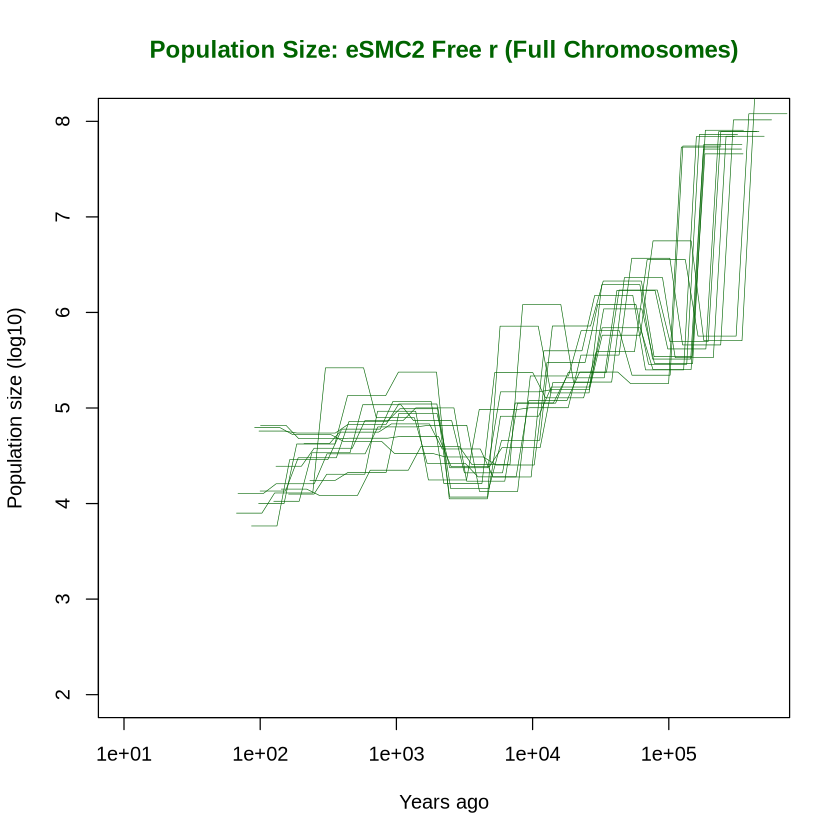

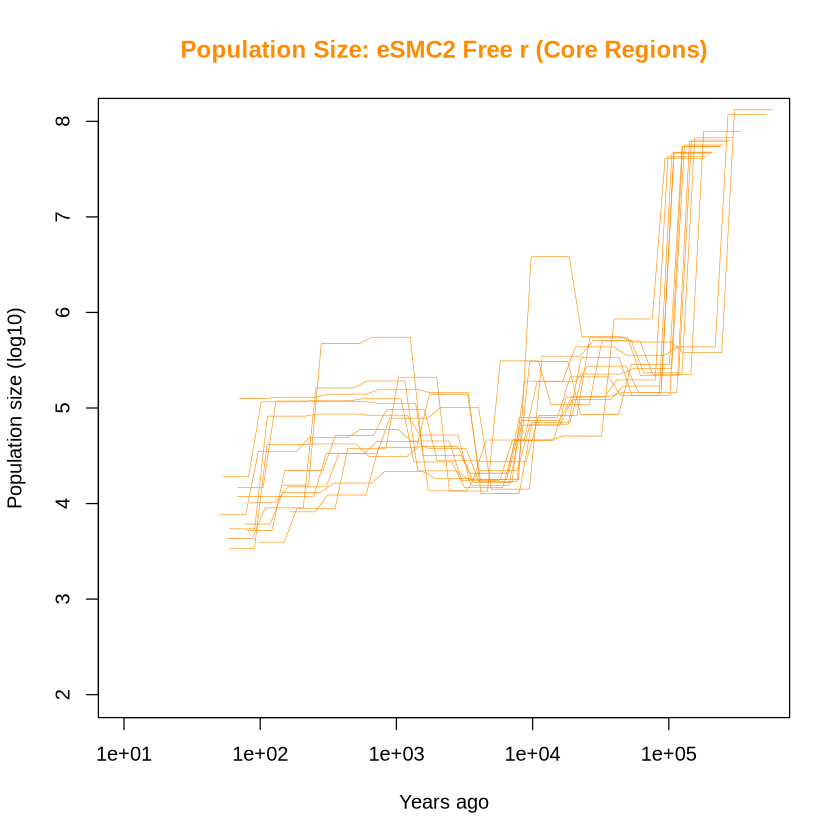

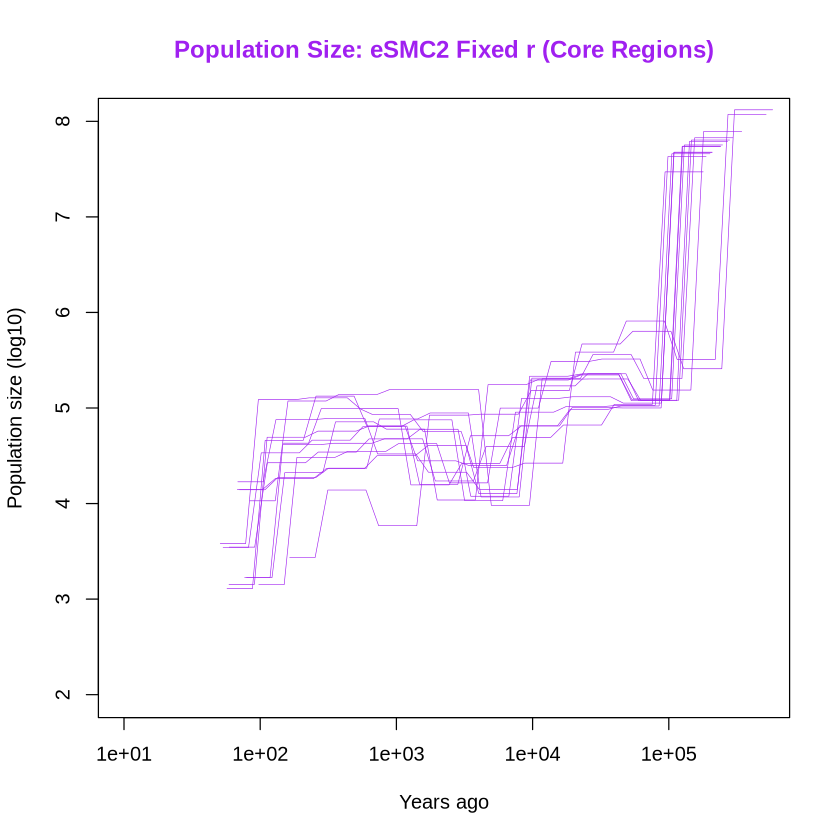

In [53]:
# Set mutation rate and generation time
mu <- 4.0425e-09  # Default mutation rate
gen <- 0.164      # Generation time

par(bg = "white")  # Applies white background to all plots

# Function to set up the plotting area
setup_plot <- function(title, color) {
  plot(c(1000, 5 * 10^7), 
       c(1, 1), 
       log = "x", 
       ylim = c(2, 8), 
       xlim = c(10, 5 * 10^5), 
       type = "n", 
       xlab = "Years ago", 
       ylab = "Population size (log10)", 
       main = title, 
       col.main = color)
}

# Plot for eSMC2 Free r Full Chromosomes
setup_plot("Population Size: eSMC2 Free r (Full Chromosomes)", "darkgreen")
for (chr in names(plot_data_list_newhetfile_esmc2_free_r)) {
  if (chr != "allchr" && !is.null(plot_data_list_newhetfile_esmc2_free_r[[chr]])) {
    Ne_t <- plot_data_list_newhetfile_esmc2_free_r[[chr]]$Xi
    Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[[chr]]$mu / mu)
    lines(plot_data_list_newhetfile_esmc2_free_r[[chr]]$Tc * Ne * gen,
          log10(Ne_t * Ne), col = "darkgreen", lwd = 0.5)
  }

}

# Plot for eSMC2 Free r Core Regions
setup_plot("Population Size: eSMC2 Free r (Core Regions)", "darkorange")
for (chr in names(plot_data_list_newhetfile_esmc2_regions)) {
  if (chr != "allchr" && !is.null(plot_data_list_newhetfile_esmc2_regions[[chr]][[1]])) {
    Ne_t <- plot_data_list_newhetfile_esmc2_regions[[chr]][[1]]$Xi
    Ne <- mean(plot_data_list_newhetfile_esmc2_regions[[chr]][[1]]$mu / mu)
    lines(plot_data_list_newhetfile_esmc2_regions[[chr]][[1]]$Tc * Ne * gen,
          log10(Ne_t * Ne), col = "darkorange", lwd = 0.5)
  }
}

# Plot for eSMC2 Fixed r Core Regions
setup_plot("Population Size: eSMC2 Fixed r (Core Regions)", "purple")
for (chr in names(plot_data_list_newhetfile_esmc2_regions_fixed_r)) {
  if (chr != "allchr" && !is.null(plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]][[1]])) {
    Ne_t <- plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]][[1]]$Xi
    Ne <- mean(plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]][[1]]$mu / mu)
    lines(plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]][[1]]$Tc * Ne * gen,
          log10(Ne_t * Ne), col = "purple", lwd = 0.5)
  }
}

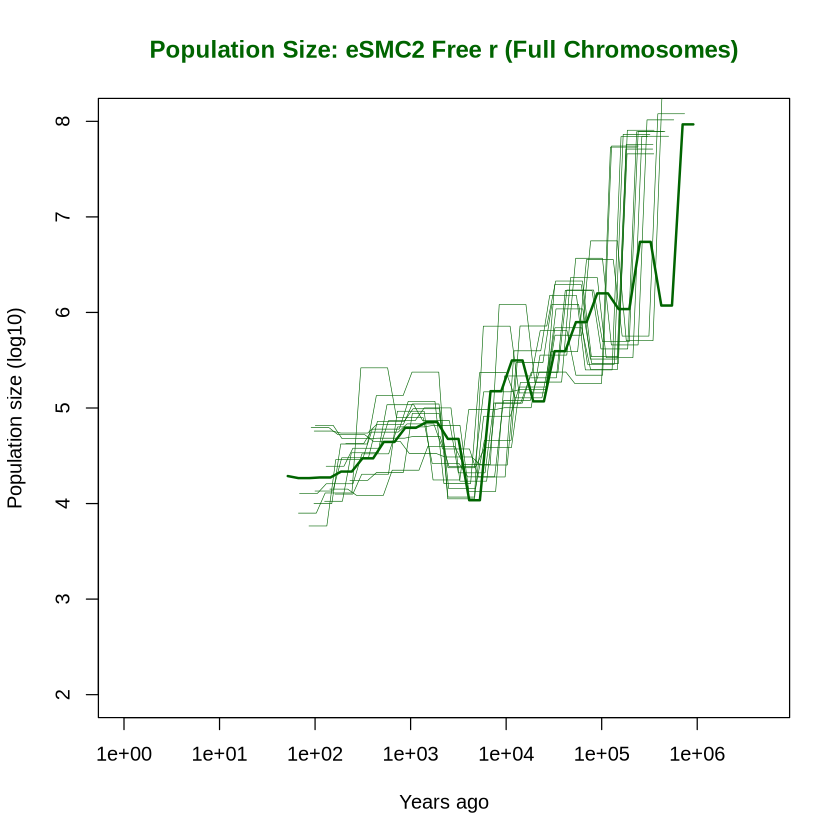

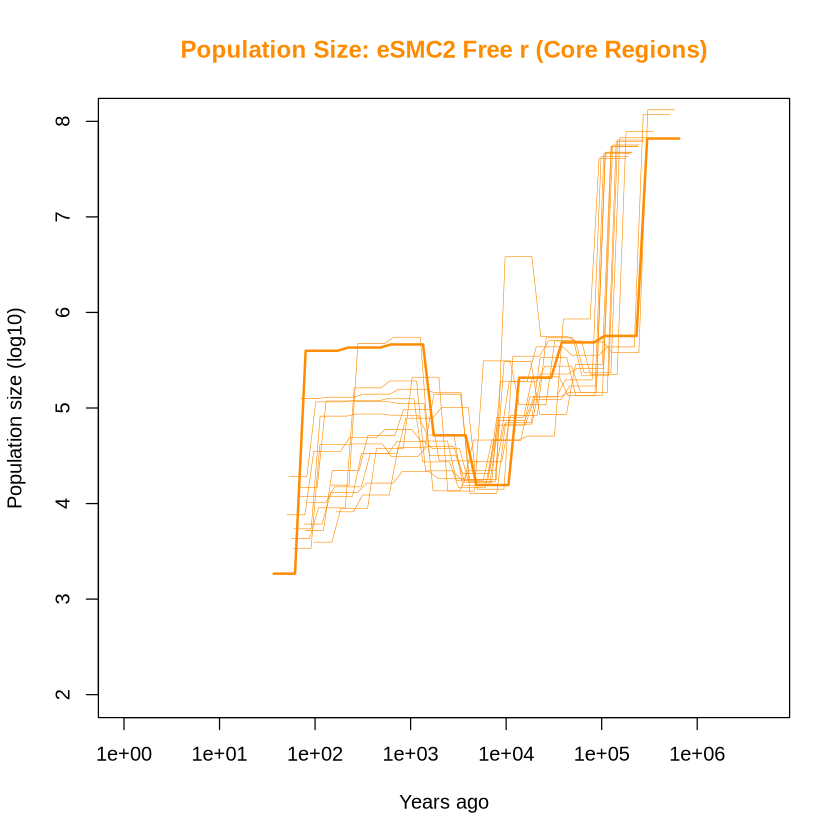

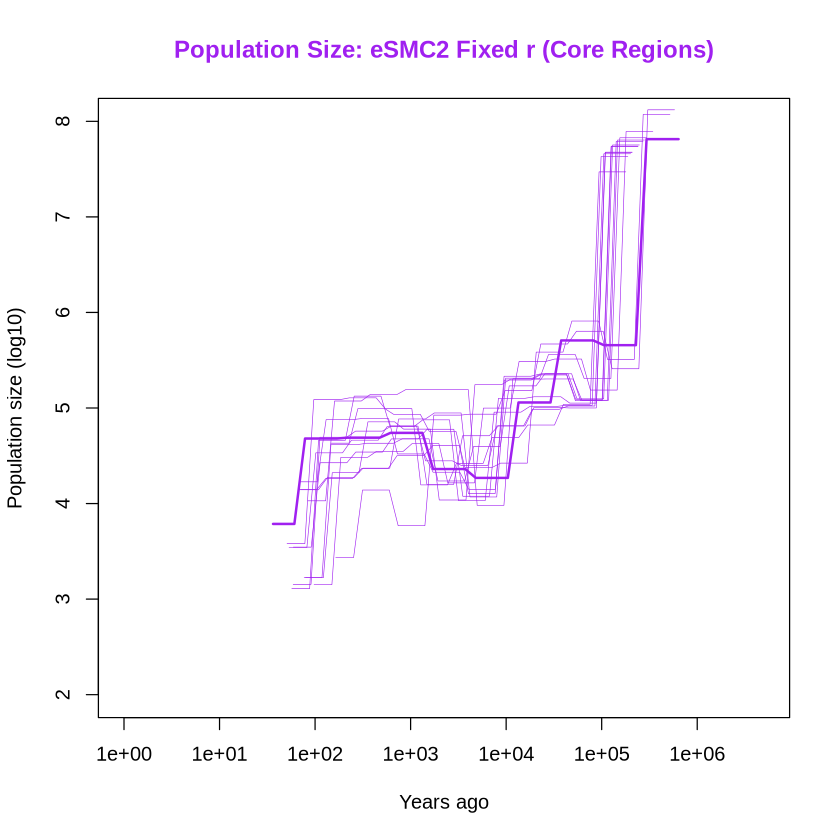

In [59]:
# Set mutation rate and generation time
mu <- 4.0425e-09  # Default mutation rate
gen <- 0.164      # Generation time

par(bg = "white")  # Applies white background to all plots

# Function to set up the plotting area
setup_plot <- function(title, color) {
  plot(c(1000, 5 * 10^7), 
       c(1, 1), 
       log = "x", 
       ylim = c(2, 8), 
       xlim = c(1, 5 * 10^6), 
       type = "n", 
       xlab = "Years ago", 
       ylab = "Population size (log10)", 
       main = title, 
       col.main = color)
}

# Plot for eSMC2 Free r Full Chromosomes
setup_plot("Population Size: eSMC2 Free r (Full Chromosomes)", "darkgreen")
for (chr in names(plot_data_list_newhetfile_esmc2_free_r)) {
  if (chr != "allchr" && !is.null(plot_data_list_newhetfile_esmc2_free_r[[chr]])) {
    Ne_t <- plot_data_list_newhetfile_esmc2_free_r[[chr]]$Xi
    Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[[chr]]$mu / mu)
    lines(plot_data_list_newhetfile_esmc2_free_r[[chr]]$Tc * Ne * gen,
          log10(Ne_t * Ne), col = "darkgreen", lwd = 0.5)
  }
}
if (!is.null(plot_data_list_newhetfile_esmc2_free_r[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_free_r[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "darkgreen", lwd = 2)
}

# Plot for eSMC2 Free r Core Regions
setup_plot("Population Size: eSMC2 Free r (Core Regions)", "darkorange")
for (chr in names(plot_data_list_newhetfile_esmc2_regions)) {
  if (chr != "allchr" && !is.null(plot_data_list_newhetfile_esmc2_regions[[chr]][[1]])) {
    Ne_t <- plot_data_list_newhetfile_esmc2_regions[[chr]][[1]]$Xi
    Ne <- mean(plot_data_list_newhetfile_esmc2_regions[[chr]][[1]]$mu / mu)
    lines(plot_data_list_newhetfile_esmc2_regions[[chr]][[1]]$Tc * Ne * gen,
          log10(Ne_t * Ne), col = "darkorange", lwd = 0.5)
  }
}
if (!is.null(plot_data_list_newhetfile_esmc2_regions[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_regions[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_regions[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_regions[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "darkorange", lwd = 2)
}

# Plot for eSMC2 Fixed r Core Regions
setup_plot("Population Size: eSMC2 Fixed r (Core Regions)", "purple")
for (chr in names(plot_data_list_newhetfile_esmc2_regions_fixed_r)) {
  if (chr != "allchr" && !is.null(plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]][[1]])) {
    Ne_t <- plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]][[1]]$Xi
    Ne <- mean(plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]][[1]]$mu / mu)
    lines(plot_data_list_newhetfile_esmc2_regions_fixed_r[[chr]][[1]]$Tc * Ne * gen,
          log10(Ne_t * Ne), col = "purple", lwd = 0.5)
  }
}
if (!is.null(plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]])) {
  Ne_t <- plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]]$Xi
  Ne <- mean(plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]]$mu / mu)
  lines(plot_data_list_newhetfile_esmc2_regions_fixed_r[["allchr"]]$Tc * Ne * gen,
        log10(Ne_t * Ne), col = "purple", lwd = 2)
}


In [8]:
# Create the data frame
df <- data.frame(
  time = plot_data_list_newhetfile_esmc2_regions[["allchr"]]$Tc * Ne,
  popsize = Ne_t * Ne
)

# Add a column for log10(popsize)
df$log10_popsize <- log10(df$popsize)

# Save the data frame as a tab-separated text file
write.table(df, file = "population_size_over_time.txt", sep = "\t", row.names = FALSE, quote = FALSE)


In [15]:
Ne_t <- plot_data_list_newhetfile_esmc2_regions[["allchr"]]$Xi
Ne <- mean(plot_data_list_newhetfile_esmc2_regions[["allchr"]]$mu / mu)

c(Ne_t * Ne)

[1]     1845.981     1845.981     1845.981     1845.981   397184.164
 [6]   397184.164   397184.164   397184.164   429158.735   429158.735
[11]   429158.735   429158.735   462435.739   462435.739   462435.739
[16]   462435.739    51738.896    51738.896    51738.896    51738.896
[21]    15626.022    15626.022    15626.022    15626.022   207592.565
[26]   207592.565   207592.565   207592.565   485421.818   485421.818
[31]   485421.818   485421.818   567563.337   567563.337   567563.337
[36]   567563.337 66123729.270 66123729.270 66123729.270 66123729.270

In [71]:
# Initialize vectors for rho, mu, rho/mu, chromosomes, and categories
rho_values <- c()
mu_values <- c()
rho_mu_ratios <- c()
chromosomes <- c()
category_labels <- c()
chr_no <- sprintf("%02d", 1:14)

# Function to process data from a given list and category
process_data <- function(data_list, category_label) {
    for (chr in as.numeric(names(data_list))) {
        chr_data <- data_list[[chr]][[1]]
        
        if (!is.null(chr_data$rho) && !is.null(chr_data$mu)) {
            rho_values <<- c(rho_values, mean(chr_data$rho))
            mu_values <<- c(mu_values, chr_data$mu)
            rho_mu_ratios <<- c(rho_mu_ratios, mean(chr_data$rho) / chr_data$mu)
            chromosomes <<- c(chromosomes, chr)
            category_labels <<- c(category_labels, as.character(category_label))
        }
    }
}

process_data(plot_data_list_newhetfile_esmc2_regions, "Free r Core Regions")
process_data(plot_data_list_newhetfile_esmc2_regions_fixed_r, "Fixed r Core Regions")





Warning message in process_data(plot_data_list_newhetfile_esmc2_regions, "Free r Core Regions"):
“NAs introduced by coercion”
Warning message in process_data(plot_data_list_newhetfile_esmc2_regions_fixed_r, :
“NAs introduced by coercion”


In [47]:
length(mu_values)

[1] 28

In [72]:

# Function to process data from a given list and category
process_data <- function(data_list, category_label) {
    for (chr in names(data_list)) {
        chr_data <- data_list[[chr]]
        
        if (!is.null(chr_data$rho) && !is.null(chr_data$mu)) {
            rho_values <<- c(rho_values, mean(chr_data$rho))
            mu_values <<- c(mu_values, chr_data$mu)
            rho_mu_ratios <<- c(rho_mu_ratios, mean(chr_data$rho) / chr_data$mu)
            chromosomes <<- c(chromosomes, chr)
            category_labels <<- c(category_labels, as.character(category_label))
        }
    }
}

# Process data for all categories

process_data(plot_data_list_newhetfile_esmc2_free_r, "Free r Full Chromosome")
process_data(plot_data_list_newhetfile_esmc2, "Fixed r Full Chromosome")

length(rho_values)
length(chromosomes)

[1] 58

[1] 58

In [78]:
Category = factor(category_labels, levels = c("Free r Core Regions", "Free r Full Chromosome", "Fixed r Core Regions", "Fixed r Full Chromosome")) # Ensure correct category order

In [79]:
chr_no <- rep(sprintf("%02d", 1:14), times = 4)
full_data<-cbind(chromosomes,rho_values,mu_values,rho_mu_ratios,category_labels)
full_data[,1]

[1] "1"      "2"      "3"      "4"      "5"      "6"      "7"      "8"     
 [9] "9"      "10"     "11"     "12"     "13"     "14"     "1"      "2"     
[17] "3"      "4"      "5"      "6"      "7"      "8"      "9"      "10"    
[25] "11"     "12"     "13"     "14"     "01"     "02"     "03"     "04"    
[33] "05"     "06"     "07"     "08"     "09"     "10"     "11"     "12"    
[41] "13"     "14"     "allchr" "01"     "02"     "03"     "04"     "05"    
[49] "06"     "07"     "08"     "09"     "10"     "11"     "12"     "13"    
[57] "14"     "allchr"

In [85]:
chr_no

[1] "01" "02" "03" "04" "05" "06" "07" "08" "09" "10" "11" "12" "13" "14" "01"
[16] "02" "03" "04" "05" "06" "07" "08" "09" "10" "11" "12" "13" "14" "01" "02"
[31] "03" "04" "05" "06" "07" "08" "09" "10" "11" "12" "13" "14" "01" "02" "03"
[46] "04" "05" "06" "07" "08" "09" "10" "11" "12" "13" "14"

In [88]:


# Create a data frame for plotting
boxplot_data <- data.frame(
    chromosomes=chromosomes,
    Rho = rho_values,
    Mu = mu_values,
    Rho_Mu_Ratio = rho_mu_ratios,
    Category = factor(category_labels, levels = c("Free r Core Regions", "Free r Full Chromosome", "Fixed r Core Regions", "Fixed r Full Chromosome")) # Ensure correct category order
)
boxplot_data<-boxplot_data %>% filter(chromosomes != "allchr")
length(boxplot_data[,1])

[1] 56

In [89]:
length(chr_no)

[1] 56

In [90]:
boxplot_data[,"chromosomes"]<-chr_no
boxplot_data

chromosomes,Rho,Mu,Rho_Mu_Ratio,Category
<chr>,<dbl>,<dbl>,<dbl>,<fct>
01,0.013560824,0.0004780770,28.365358,Free r Core Regions
02,0.014617702,0.0002494017,58.611089,Free r Core Regions
03,0.024438795,0.0002220733,110.048332,Free r Core Regions
04,0.020751712,0.0005338957,38.868479,Free r Core Regions
05,0.007909709,0.0001913689,41.332259,Free r Core Regions
06,0.006783495,0.0001850675,36.654161,Free r Core Regions
07,0.012601099,0.0003165284,39.810333,Free r Core Regions
08,0.005875533,0.0002576262,22.806424,Free r Core Regions
09,0.008335844,0.0002288291,36.428243,Free r Core Regions


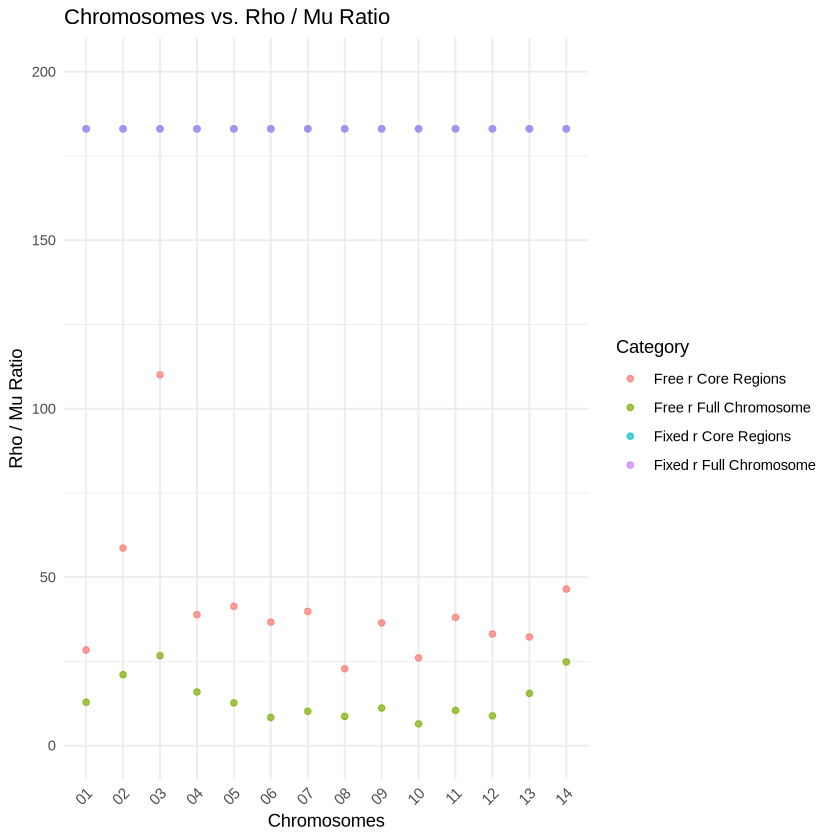

In [91]:


# Create the dot plot
ggplot(boxplot_data, aes(x = chr_no, y = Rho_Mu_Ratio, color = Category)) +
  geom_point( alpha = 0.7) +
  labs(x = "Chromosomes", y = "Rho / Mu Ratio", title = "Chromosomes vs. Rho / Mu Ratio") +
  theme_minimal() +
  ylim(0,200)+
  theme(axis.text.x = element_text(angle = 45, hjust = 1))  # Rotate x-axis labels for readability


In [37]:
boxplot_free_r<-boxplot_data%>% filter(,Category=="Free r Full Chromosome" | Category=="Free r Core Regions")

In [30]:
write.table(boxplot_free_r, "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/scripts_msmc_esmc/plot_esmc_msmc/boxplot_free_r", sep='\t',quote=F, row.names = FALSE)

In [40]:
boxplot_data<- boxplot_data %>% filter(chromosomes != "allchr")
length(boxplot_data[,1])

[1] 812

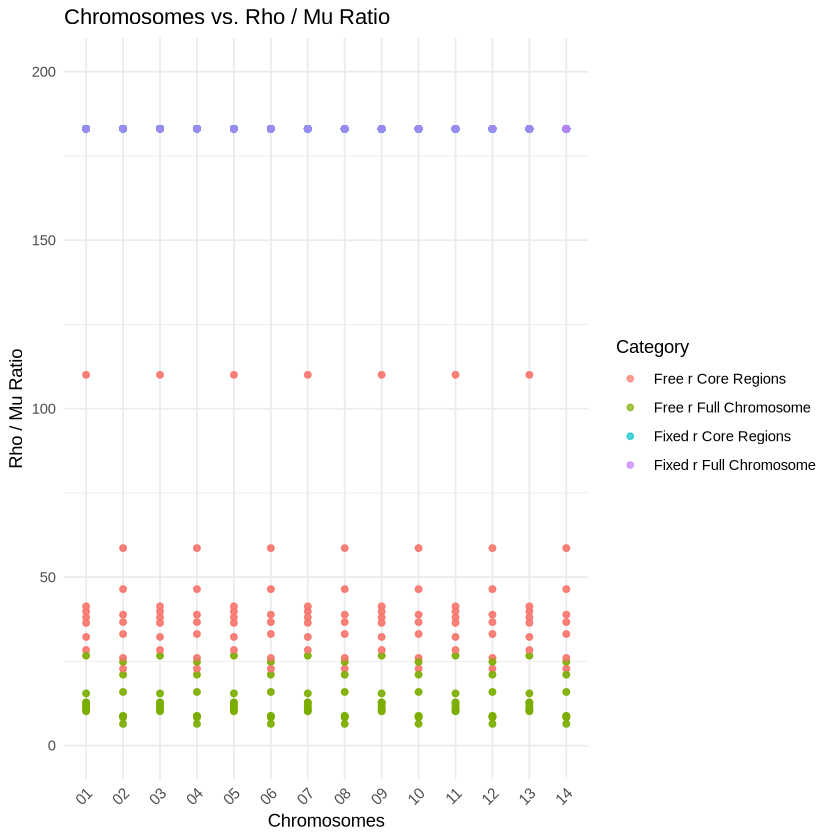

In [39]:


# Create the dot plot
ggplot(boxplot_data, aes(x = chromosomes, y = Rho_Mu_Ratio, color = Category)) +
  geom_point( alpha = 0.7) +
  labs(x = "Chromosomes", y = "Rho / Mu Ratio", title = "Chromosomes vs. Rho / Mu Ratio") +
  theme_minimal() +
  ylim(0,200)+
  theme(axis.text.x = element_text(angle = 45, hjust = 1))  # Rotate x-axis labels for readability


Warning message:
“The dot-dot notation (`..y..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(y)` instead.”
Warning message:
“Removed 28 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 28 rows containing non-finite outside the scale range
(`stat_summary()`).”


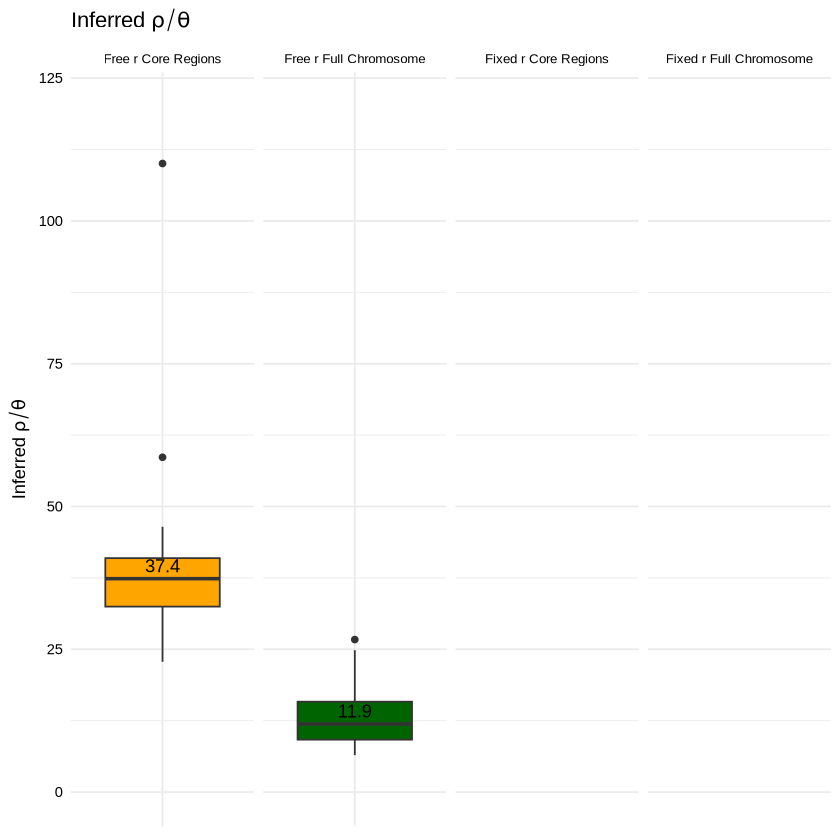

In [20]:
# Boxplot for Rho/Mu with median labels
plot_rho_mu <- ggplot(boxplot_data, aes(x = Category, y = Rho_Mu_Ratio, fill = Category)) +
    geom_boxplot() +
    labs(
        title = expression("Inferred " * rho / theta),  # Title with inferred rho/mu
        y = expression("Inferred " * rho / theta)      # Y-axis label with inferred rho/mu
    ) +
    scale_fill_manual(
        values = c("orange", "darkgreen", "purple", "lightcoral"),
        name = "Category"
    ) +
    theme_minimal() +

    facet_wrap(~Category, scales = "free_x", ncol = 4) +  # Separate plots by Category
    stat_summary(
        fun = median, 
        geom = "text", 
        aes(label = round(..y.., 1)),                  # Round median to 1 decimal place
        position = position_dodge(width = 0.75), 
        vjust = -0.5,                                 # Adjust position of text
        color = "black"                               # Set text color
    ) +
    ylim(0,120)+
    theme(
        axis.text.x = element_blank(),               # Remove x-axis tick labels
        axis.title.x = element_blank(),              # Remove x-axis label
        axis.text = element_text(color = "black"),   # Black tick labels
        axis.title = element_text(color = "black"),  # Black axis labels
        plot.title = element_text(color = "black"),  # Black plot title
        strip.text = element_text(size = 8, color = "black"),  # Category labels font size and color
        legend.position = "none"                     # Remove legend
    )

# Display the plot
plot_rho_mu



In [20]:
# Combine the plots with one shared legend at the bottom
combined_plot <- (plot_rho + plot_mu + plot_rho_mu) +
    plot_layout(guides = "collect") &                 # Combine legends
    theme(legend.position = "bottom")                 # Place legend at the bottom

# Add a header using plot_annotation()
combined_plot <- combined_plot +
    plot_annotation(
        title = "Comparison of Rho, Mu, and Rho/Mu Across Categories",
        theme = theme(
            plot.title = element_text(size = 16, face = "bold", hjust = 0.5, color = "black") # Centered and bold title
        )
    )

# Display the combined plot
print(combined_plot)

ERROR: Error: object 'plot_rho' not found


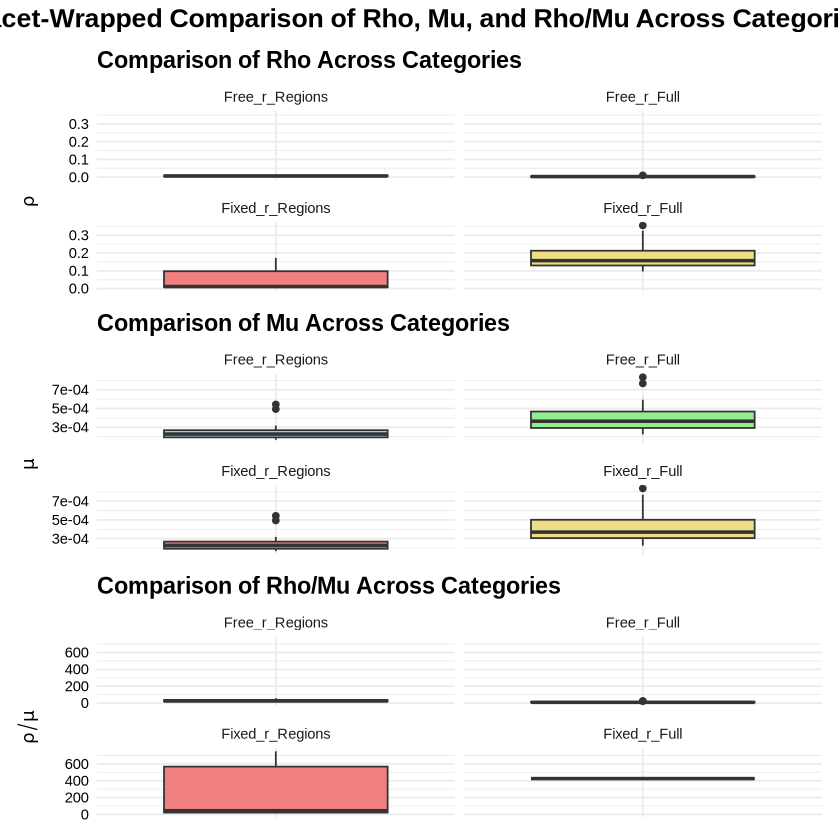

In [52]:

# Combine the facet plots into a single layout
combined_facet_plot <- (plot_rho_facet / plot_mu_facet / plot_rho_mu_facet) +  # Arrange the plots vertically
    plot_annotation(
        title = "Facet-Wrapped Comparison of Rho, Mu, and Rho/Mu Across Categories",
        theme = theme(
            plot.title = element_text(size = 16, face = "bold", hjust = 0.5, color = "black") # Centered and bold title
        )
    )

# Display the combined facet plot
print(combined_facet_plot)